# BCM power and profiles

# BCM Mass-Dependent Power Analysis

This notebook analyzes how well mass-dependent BCM models reproduce TNG power spectra.

**BCM Models (Arico20 with TNG-fitted parameters):**
- `arico20_tng_Mlow`: Fit to halos with 10^12.0 < M < 10^12.5 M⊙/h
- `arico20_tng_Mmid_low`: Fit to halos with 10^12.5 < M < 10^13.0 M⊙/h  
- `arico20_tng_Mmid_high`: Fit to halos with 10^13.0 < M < 10^13.5 M⊙/h
- `arico20_tng_Mhigh`: Fit to halos with M > 10^13.5 M⊙/h
- `arico20_tng_joint`: Single parameter set fit jointly to all mass bins

**Data locations:**
- Hydro/DMO lensplanes: `/mnt/home/mlee1/ceph/hydro_replace_LP/L205n2500TNG/`
- BCM lensplanes: `/mnt/home/mlee1/ceph/hydro_replace_LP_bcm/L205n2500TNG/`

In [1]:
import Pk_library as PKL
import numpy as np
import matplotlib.pyplot as plt
import os
import scienceplots
plt.style.use(['science', 'notebook'])

In [2]:
def compute_Pk_2d(field, box_size=205.0):
    """
    Compute 2D power spectrum using Pylians.
    
    Parameters
    ----------
    field : np.ndarray
        2D density field
    box_size : float, optional
        Box size in Mpc/h (default: 205.0)
    
    Returns
    -------
    k : np.ndarray
        Wavenumber bins (h/Mpc)
    Pk : np.ndarray
        Power spectrum values (Mpc/h)²
    """
    import Pk_library as PKL
    
    # Convert to overdensity
    mean_val = np.nanmean(field)
    field[np.isnan(field)==True] = 0
    if mean_val > 0:
        delta = (field - mean_val) / mean_val
    else:
        delta = field.copy()
    delta = delta.astype(np.float32)
    # delta[np.isnan(delta)] = 0
    
    # Compute P(k)
    Pk2D = PKL.Pk_plane(delta, box_size, 'CIC', 1, verbose=False)
    k = Pk2D.k
    Pk = Pk2D.Pk
    
    return k, Pk

In [3]:
def read_lensplane(path, expected_grid=4096):
    """
    Load lensplane from binary dat format.
    
    Handles two formats:
    1. Standard lensplanes (DMO/Hydro): int32 grid_size + float64 data
    2. BCM lensplanes: Fortran record format with float32 data
    
    Parameters
    ----------
    path : str
        Path to lenspot*.dat file
    expected_grid : int, optional
        Expected grid size (default: 4096). Used for format detection.
    
    Returns
    -------
    np.ndarray
        2D mass plane
    """
    import os
    file_size = os.path.getsize(path)
    
    # Expected sizes for 4096 grid
    size_float64 = 4 + expected_grid * expected_grid * 8  # int32 header + float64 data
    size_float32_fortran = 4 + expected_grid * expected_grid * 4 + 4  # Fortran: int32 + float32 + int32
    
    with open(path, 'rb') as f:
        if abs(file_size - size_float64) < 100:
            # Standard format: int32 grid_size + float64 data
            gs = np.fromfile(f, dtype=np.int32, count=1)[0]
            data = np.fromfile(f, dtype=np.float64, count=gs*gs)
            return data.reshape(gs, gs)
        
        elif abs(file_size - size_float32_fortran) < 100:
            print('err')
            # BCM format: Fortran record with float32 data
            # Header contains record size in bytes
            record_bytes = np.fromfile(f, dtype=np.int32, count=1)[0]
            n_elements = record_bytes // 4  # float32 = 4 bytes
            grid_size = int(np.sqrt(n_elements))
            
            data = np.fromfile(f, dtype=np.float32, count=n_elements)
            # Convert to float64 for consistency
            return data.reshape(grid_size, grid_size).astype(np.float64)
        
        else:
            raise ValueError(f"Unknown file format. Size={file_size}, expected ~{size_float64} or ~{size_float32_fortran}")

print("Updated read_lensplane to handle both standard (float64) and BCM (float32 Fortran) formats")

Updated read_lensplane to handle both standard (float64) and BCM (float32 Fortran) formats


In [4]:
# Define paths
LP_BASE = '/mnt/home/mlee1/ceph/hydro_replace_LP/L205n2500TNG'
BCM_BASE = '/mnt/home/mlee1/ceph/hydro_replace_LP_bcm/L205n2500TNG'

# Mass-dependent BCM models (Arico20 fit to TNG profiles per mass bin)
BCM_MODELS_MASS_DEP = [
    'arico20_tng_Mlow',      # 10^12.0 - 10^12.5 M⊙/h
    'arico20_tng_Mmid_low',  # 10^12.5 - 10^13.0 M⊙/h
    'arico20_tng_Mmid_high', # 10^13.0 - 10^13.5 M⊙/h
    'arico20_tng_Mhigh',     # M > 10^13.5 M⊙/h
    'arico20_tng_joint',     # Joint fit to all mass bins
]

# Mass ranges for each model (log10 M⊙/h)
MASS_RANGES = {
    'arico20_tng_Mlow': (12.0, 12.5),
    'arico20_tng_Mmid_low': (12.5, 13.0),
    'arico20_tng_Mmid_high': (13.0, 13.5),
    'arico20_tng_Mhigh': (13.5, 15.0),  # All M > 10^13.5
    'arico20_tng_joint': (12.0, 15.0),   # All M > 10^12
}

# Old BCM models for comparison (if available)
BCM_MODELS_OLD = ['arico20']

BOX_SIZE = 205.0  # Mpc/h

# Check which models exist
print("Checking available BCM models...")
for model in BCM_MODELS_MASS_DEP + BCM_MODELS_OLD:
    model_path = f'{BCM_BASE}/{model}/LP_00/lenspot00.dat'
    exists = os.path.exists(model_path)
    status = "✓" if exists else "✗ (not ready)"
    print(f"  {model}: {status}")

Checking available BCM models...
  arico20_tng_Mlow: ✓
  arico20_tng_Mmid_low: ✓
  arico20_tng_Mmid_high: ✓
  arico20_tng_Mhigh: ✓
  arico20_tng_joint: ✓
  arico20: ✓


In [5]:
# Load DMO and Hydro lensplanes (lenspot00 = z ~ 0.04)
dmo_plane = read_lensplane(f'{LP_BASE}/dmo/LP_00/lenspot00.dat')
hydro_plane = read_lensplane(f'{LP_BASE}/hydro/LP_00/lenspot00.dat')

print(f"DMO plane shape: {dmo_plane.shape}, mean: {dmo_plane.mean():.4e}")
print(f"Hydro plane shape: {hydro_plane.shape}, mean: {hydro_plane.mean():.4e}")

DMO plane shape: (4096, 4096), mean: 2.2304e+10
Hydro plane shape: (4096, 4096), mean: 2.2304e+10


In [6]:
# Load BCM lensplanes - try mass-dependent models first, fall back to old models
BCM_MODELS = BCM_MODELS_MASS_DEP.copy()  # Primary: mass-dependent models

bcm_planes = {}
for model in BCM_MODELS:
    path = f'{BCM_BASE}/{model}/LP_00/lenspot00.dat'
    try:
        bcm_planes[model] = read_lensplane(path)
        # Use nanmean since there may be a few NaN pixels at edges
        n_nan = np.sum(np.isnan(bcm_planes[model]))
        print(f"✓ {model}: loaded, shape={bcm_planes[model].shape}, nanmean: {np.nanmean(bcm_planes[model]):.4e}, NaN pixels: {n_nan}")
    except FileNotFoundError:
        print(f"✗ {model}: NOT FOUND (job may still be running)")

# Also try to load old models for comparison
print("\n--- Old BCM models (for comparison) ---")
for model in BCM_MODELS_OLD:
    path = f'{BCM_BASE}/{model}/LP_00/lenspot00.dat'
    try:
        bcm_planes[model] = read_lensplane(path)
        print(f"✓ {model}: loaded")
    except FileNotFoundError:
        print(f"✗ {model}: NOT FOUND")

print(f"\n✓ Loaded {len(bcm_planes)} BCM models total")

✓ arico20_tng_Mlow: loaded, shape=(4096, 4096), nanmean: 2.2304e+10, NaN pixels: 0
✓ arico20_tng_Mmid_low: loaded, shape=(4096, 4096), nanmean: 2.2304e+10, NaN pixels: 0
✓ arico20_tng_Mmid_high: loaded, shape=(4096, 4096), nanmean: 2.2304e+10, NaN pixels: 0
✓ arico20_tng_Mhigh: loaded, shape=(4096, 4096), nanmean: 2.2305e+10, NaN pixels: 0
✓ arico20_tng_joint: loaded, shape=(4096, 4096), nanmean: 2.2304e+10, NaN pixels: 0

--- Old BCM models (for comparison) ---
✓ arico20: loaded

✓ Loaded 6 BCM models total


In [7]:
# Compute power spectra
k_dmo, Pk_dmo = compute_Pk_2d(dmo_plane, BOX_SIZE)
k_hydro, Pk_hydro = compute_Pk_2d(hydro_plane, BOX_SIZE)

# Compute for all BCM models
bcm_Pk = {}
for model, plane in bcm_planes.items():
    k, Pk = compute_Pk_2d(plane, BOX_SIZE)
    bcm_Pk[model] = (k, Pk)

print(f"k range: {k_dmo.min():.4f} to {k_dmo.max():.2f} h/Mpc")

k range: 0.0370 to 88.77 h/Mpc


In [8]:
BOX_SIZE = 205  # Mpc/h
GRID_3D = 4096  # 3D density grid
K_NYQUIST = np.pi * GRID_3D / BOX_SIZE  # for P(k)

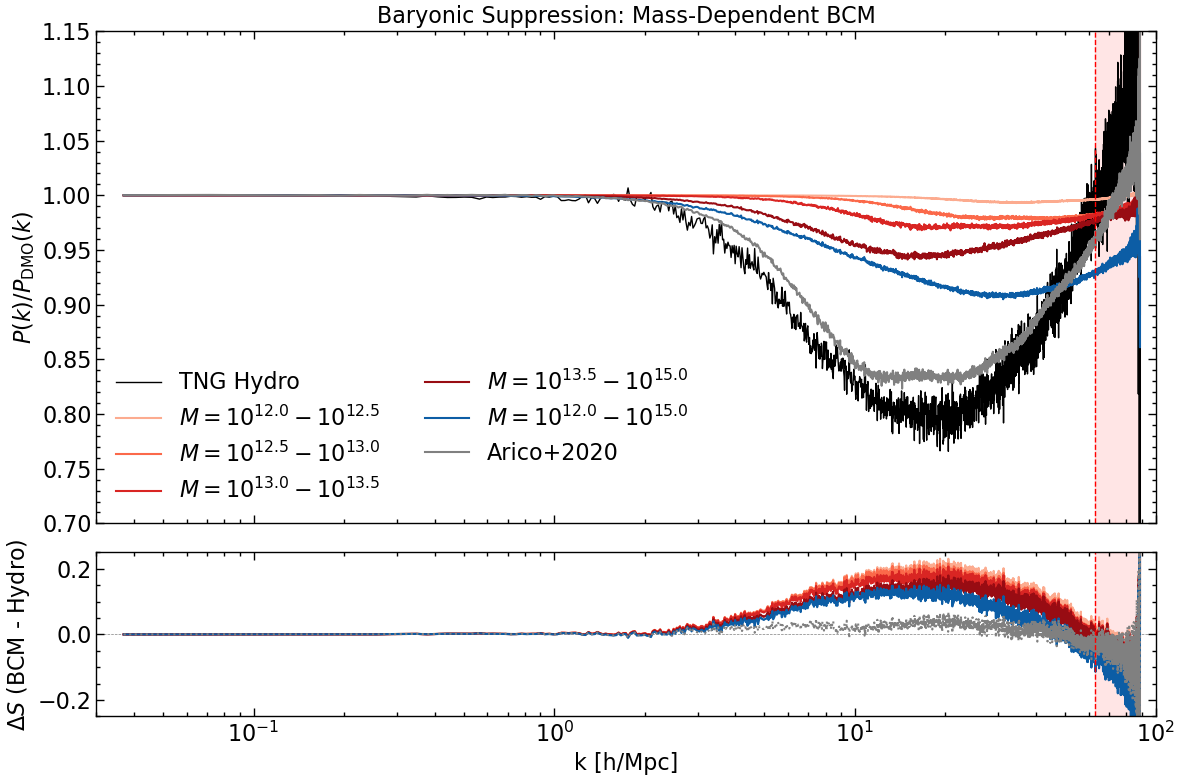

In [9]:
# Plot power spectrum suppression: P(k)/P_DMO(k)
fig, axes = plt.subplots(2, 1, figsize=(12, 8), height_ratios=[3, 1], sharex=True)

# Define colors for mass-dependent models using Reds cmap (darker = higher mass)
from matplotlib import cm
reds = cm.Reds
mass_dep_colors = {
    'arico20_tng_Mlow': reds(0.3),
    'arico20_tng_Mmid_low': reds(0.5), 
    'arico20_tng_Mmid_high': reds(0.7),
    'arico20_tng_Mhigh': reds(0.9),
    'arico20_tng_joint': 'C0',  # Blue
}
old_colors = {'arico20': 'gray', 'schneider19': 'darkgray', 'arico20_mass_dependent': 'silver'}

# Top: Suppression ratio
ax = axes[0]
# ax.axhline(1, color='k', ls='--', alpha=0.5, lw=0.5)

# True hydro suppression (target)
suppression_hydro = Pk_hydro / Pk_dmo
ax.semilogx(k_hydro, suppression_hydro, 'k-', lw=1., label='TNG Hydro')

# BCM suppression
for model, (k, Pk) in bcm_Pk.items():
    color = mass_dep_colors.get(model, old_colors.get(model, 'gray'))
    ls = '-' if model in mass_dep_colors else '-'
    alpha = 1.0 if model in mass_dep_colors else 1.0
    lw = 1.5 if model in mass_dep_colors else 1.5
    suppression = Pk / Pk_dmo
    label = model
    if model in MASS_RANGES:
        m_lo, m_hi = MASS_RANGES[model]
        label = rf'$M=10^{{{m_lo:.1f}}}-10^{{{m_hi:.1f}}}$'
    elif model == 'arico20_tng_joint':
        label = 'Joint fit'
    else:
        label ='Arico+2020'
    ax.semilogx(k, suppression, ls, color=color, lw=lw, alpha=alpha, label=label)

ax.set_ylabel(r'$P(k) / P_{\rm DMO}(k)$')
ax.set_xlim(0.03, 100)
ax.set_ylim(0.7, 1.15)
ax.axvline(K_NYQUIST, color='red', ls='--', lw=1,)
ax.fill_between([K_NYQUIST, k.max()], 0.7, 1.15, color='red', alpha=0.1)
ax.legend(loc='lower left', ncol=2)
ax.set_title('Baryonic Suppression: Mass-Dependent BCM')

# Bottom: Difference between BCM and Hydro
ax = axes[1]
ax.axhline(0, color='k', ls='--', alpha=0.5, lw=0.5)

for model, (k, Pk) in bcm_Pk.items():
    color = mass_dep_colors.get(model, old_colors.get(model, 'gray'))
    ls = '-' if model in mass_dep_colors else ':'
    alpha = 1.0 if model in mass_dep_colors else 1.0
    lw = 1.5 if model in mass_dep_colors else 1.5
    
    # Compute difference: BCM suppression - Hydro suppression
    suppression_bcm = Pk / Pk_dmo
    diff = suppression_bcm - suppression_hydro
    
    label = model
    if model in MASS_RANGES:
        m_lo, m_hi = MASS_RANGES[model]
        label = rf'$M=10^{{{m_lo:.1f}}}-10^{{{m_hi:.1f}}}$'
    elif model == 'arico20_tng_joint':
        label = 'Joint fit'
    else:
        label ='Arico+2020'
    ax.semilogx(k, diff, ls, color=color, lw=lw, alpha=alpha, label=label)

ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel(r'$\Delta S$ (BCM - Hydro)')
ax.set_xlim(0.03, 100)
ax.set_ylim(-0.25, 0.25)
ax.axvline(K_NYQUIST, color='red', ls='--', lw=1, label='Nyquist')
ax.fill_between([K_NYQUIST, k.max()], -0.25, 0.25, color='red', alpha=0.1)

plt.tight_layout()
plt.savefig('figures/bcm_mass_dep_suppression.png', dpi=150, bbox_inches='tight')
plt.show()

## Average over multiple LPs for better statistics

In [10]:
# Compute average power spectra over all 20 LPs
N_LP = 20

def compute_mean_Pk(base_path, model_name, n_lp=20, box_size=205.0):
    """Compute mean P(k) over multiple LP orientations."""
    Pk_list = []
    for i in range(n_lp):
        path = f'{base_path}/{model_name}/LP_{i:02d}/lenspot00.dat'
        try:
            plane = read_lensplane(path)
            k, Pk = compute_Pk_2d(plane, box_size)
            Pk_list.append(Pk)
        except FileNotFoundError:
            pass  # Skip missing LPs
    
    if len(Pk_list) == 0:
        return None, None, None
    
    Pk_mean = np.mean(Pk_list, axis=0)
    Pk_std = np.std(Pk_list, axis=0)
    return k, Pk_mean, Pk_std

# Compute for DMO and Hydro
print("Computing DMO...")
k_dmo, Pk_dmo_mean, Pk_dmo_std = compute_mean_Pk(LP_BASE, 'dmo', N_LP, BOX_SIZE)
print("Computing Hydro...")
k_hydro, Pk_hydro_mean, Pk_hydro_std = compute_mean_Pk(LP_BASE, 'hydro', N_LP, BOX_SIZE)

# Compute for mass-dependent BCM models
bcm_Pk_mean = {}
for model in BCM_MODELS_MASS_DEP:
    print(f"Computing BCM {model}...")
    k, Pk_mean, Pk_std = compute_mean_Pk(BCM_BASE, model, N_LP, BOX_SIZE)
    if k is not None:
        bcm_Pk_mean[model] = (k, Pk_mean, Pk_std)
        print(f"  ✓ {len([p for p in os.listdir(f'{BCM_BASE}/{model}') if p.startswith('LP_')])} LPs")
    else:
        print(f"  ✗ No data found")

# Also try old models
for model in BCM_MODELS_OLD:
    print(f"Computing BCM {model}...")
    k, Pk_mean, Pk_std = compute_mean_Pk(BCM_BASE, model, N_LP, BOX_SIZE)
    if k is not None:
        bcm_Pk_mean[model] = (k, Pk_mean, Pk_std)

print(f"\n✓ Done! Loaded {len(bcm_Pk_mean)} models with LP averaging.")

Computing DMO...


Computing Hydro...
Computing BCM arico20_tng_Mlow...
  ✓ 20 LPs
Computing BCM arico20_tng_Mmid_low...
  ✓ 20 LPs
Computing BCM arico20_tng_Mmid_high...
  ✓ 20 LPs
Computing BCM arico20_tng_Mhigh...
  ✓ 20 LPs
Computing BCM arico20_tng_joint...
  ✓ 20 LPs
Computing BCM arico20...

✓ Done! Loaded 6 models with LP averaging.


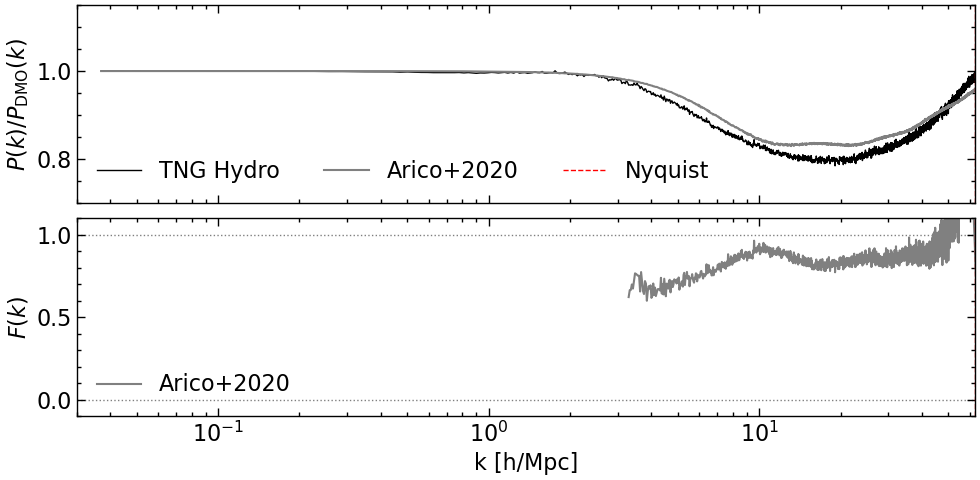

In [32]:
# Plot mean suppression with F(k) (2-panel layout)
fig, axes = plt.subplots(2, 1, figsize=(10, 5), height_ratios=[1, 1], sharex=True)

# Define colors for mass-dependent models using Reds cmap (darker = higher mass)
from matplotlib import cm
reds = cm.Reds
mass_dep_colors = {
    'arico20_tng_Mlow': reds(0.3),
    'arico20_tng_Mmid_low': reds(0.5), 
    'arico20_tng_Mmid_high': reds(0.7),
    'arico20_tng_Mhigh': reds(0.9),
    'arico20_tng_joint': 'C0',  # Blue
}
old_colors = {'arico20': 'gray', 'schneider19': 'darkgray', 'arico20_mass_dependent': 'silver'}

# Top: Suppression ratio
ax = axes[0]

# True hydro suppression (target)
suppression_hydro = Pk_hydro_mean / Pk_dmo_mean
ax.semilogx(k_hydro, suppression_hydro, 'k-', lw=1., label='TNG Hydro')

# Plot old models (dashed, lower alpha)
for model in BCM_MODELS_OLD:
    if model in bcm_Pk_mean:
        k, Pk_mean, Pk_std = bcm_Pk_mean[model]
        color = old_colors.get(model, 'gray')
        suppression = Pk_mean / Pk_dmo_mean
        ax.semilogx(k, suppression, '-', color=color, lw=1.5, alpha=1.0, label='Arico+2020')

ax.set_ylabel(r'$P(k) / P_{\rm DMO}(k)$')
ax.set_xlim(0.03, 100)
ax.set_ylim(0.7, 1.15)
ax.axvline(K_NYQUIST, color='red', ls='--', lw=1, label='Nyquist')
ax.fill_between([K_NYQUIST, k.max()], 0.7, 1.15, color='red', alpha=0.1)
ax.legend(loc='lower left', ncol=3)

# Bottom: F(k) for arico20 model
ax = axes[1]
ax.axhline(1, color='k', ls=':', alpha=0.5, lw=1)
ax.axhline(0, color='k', ls=':', alpha=0.5, lw=1)

# Compute F(k) for arico20 model
if 'arico20' in bcm_Pk_mean:
    k_bcm, Pk_bcm, Pk_std_bcm = bcm_Pk_mean['arico20']
    
    # F(k) = (P_BCM - P_DMO) / (P_Hydro - P_DMO)
    delta_bcm = Pk_bcm - Pk_dmo_mean
    delta_hydro = Pk_hydro_mean - Pk_dmo_mean
    
    with np.errstate(divide='ignore', invalid='ignore'):
        F_arico = np.where(np.abs(delta_hydro) > 1e-15, delta_bcm / delta_hydro, np.nan)
        # Mask where baryonic effect is too small
        frac_effect = np.abs(delta_hydro) / Pk_dmo_mean
        valid_mask = (frac_effect > 0.03) & np.isfinite(F_arico)
    
    # Plot F(k)
    ax.semilogx(k_bcm[valid_mask], F_arico[valid_mask], '-', color='gray', lw=1.5, label='Arico+2020')
    
    # Compute mean F for annotation
    F_mean_arico = np.nanmean(F_arico[valid_mask])
    
ax.set_xlabel('k [h/Mpc]')
ax.set_ylabel(r'$F(k)$')
ax.set_xlim(0.03, K_NYQUIST)
ax.set_ylim(-.1, 1.1)
ax.axvline(K_NYQUIST, color='red', ls='--', lw=1)
ax.fill_between([K_NYQUIST, k.max()], 0.0, 1.5, color='red', alpha=0.1)
ax.legend(loc='lower left')

plt.tight_layout()
plt.savefig('figures/bcm_mass_dep_suppression_mean.png', dpi=150, bbox_inches='tight')
plt.show()

In [33]:
# Load Pk_results from response_analysis notebook
import pickle

with open('/mnt/home/mlee1/ceph/hydro_replace_stats/Pk_results.pkl', 'rb') as f:
    Pk_results = pickle.load(f)

print(f"Loaded Pk_results with keys: {list(Pk_results.keys())}")
print(f"Cumulative models: {len(Pk_results.get('cum_F', {}))} models")
print(f"k bins shape: {Pk_results.get('bins', np.array([])).shape if 'bins' in Pk_results else 'N/A'}")

Loaded Pk_results with keys: ['cum_mean', 'disc_mean', 'base_mean', 'cum_std', 'disc_std', 'base_std', 'cum_stderr', 'disc_stderr', 'base_stderr', 'cum_F', 'cum_F_err', 'disc_F', 'disc_F_err', 'mean_cum_F', 'mean_disc_F', 'weighted_mean_cum_F', 'weighted_mean_cum_F_err', 'weighted_mean_disc_F', 'weighted_mean_disc_F_err', 'cum_integrated_scores', 'disc_integrated_scores', 'bins', 'stat_name']
Cumulative models: 16 models
k bins shape: (2896,)


In [47]:
# Diagnostic: Check Pk_std behavior
k, Pk_mean, Pk_std = bcm_Pk_mean['arico20']

print("Checking Pk_std at different scales:")
print(f"{'k':>8} | {'Pk_mean':>12} | {'Pk_std':>12} | {'Pk_std/Pk_mean':>12}")
print("-" * 50)
for idx in [0, 5, 10, 20, 50, 100, 200, -10, -1]:
    print(f"{k[idx]:8.3f} | {Pk_mean[idx]:12.3e} | {Pk_std[idx]:12.3e} | {Pk_std[idx]/Pk_mean[idx]:12.3f}")

# The issue: at large scales (low k), we have few modes, so cosmic variance is high
# But we're plotting suppression_std = Pk_std / Pk_dmo_mean
# If Pk_dmo_mean is similar to Pk_mean, this ratio should stay roughly constant
print("\n\nChecking suppression std propagation:")
suppression_mean = Pk_mean / Pk_dmo_mean
suppression_std_prop = Pk_std / Pk_dmo_mean

print(f"{'k':>8} | {'supp_mean':>10} | {'supp_std':>10} | {'frac':>10}")
print("-" * 50)
for idx in [0, 5, 10, 20, 50, 100, 200, -10, -1]:
    print(f"{k[idx]:8.3f} | {suppression_mean[idx]:10.4f} | {suppression_std_prop[idx]:10.4f} | {suppression_std_prop[idx]/abs(suppression_mean[idx] - 1):10.2f}")

Checking Pk_std at different scales:
       k |      Pk_mean |       Pk_std | Pk_std/Pk_mean
--------------------------------------------------
   0.037 |    9.518e+01 |    4.105e+01 |        0.431
   0.194 |    2.121e+01 |    4.874e+00 |        0.230
   0.348 |    1.031e+01 |    1.271e+00 |        0.123
   0.657 |    5.460e+00 |    8.752e-01 |        0.160
   1.577 |    2.258e+00 |    1.560e-01 |        0.069
   3.110 |    7.921e-01 |    4.122e-02 |        0.052
   6.175 |    2.201e-01 |    7.676e-03 |        0.035
  88.500 |    4.017e-04 |    6.206e-05 |        0.154
  88.771 |    4.018e-04 |    4.792e-04 |        1.193


Checking suppression std propagation:
       k |  supp_mean |   supp_std |       frac
--------------------------------------------------
   0.037 |     1.0000 |     0.4313 |   89377.55
   0.194 |     1.0000 |     0.2298 |   17921.85
   0.348 |     0.9999 |     0.1232 |    2074.00
   0.657 |     0.9997 |     0.1602 |     469.66
   1.577 |     0.9970 |     0.0689 |   

Computing suppression ratio per LP for proper std...


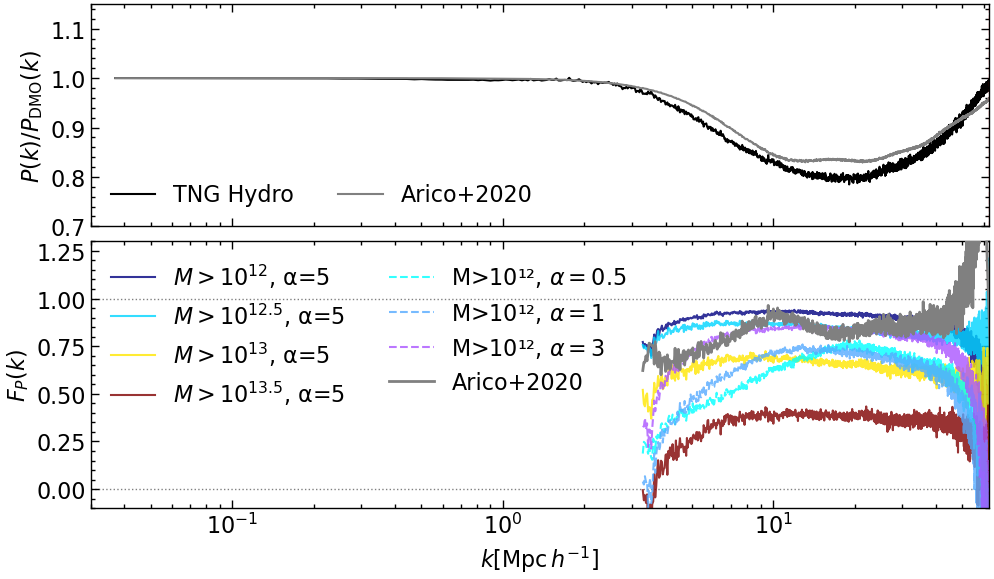

Saved: figures/bcm_vs_replace_F_comparison.png


In [52]:
# Plot BCM F(k) together with cumulative Replace model F(k)
# First, compute suppression ratio properly for each LP to get correct std

def compute_suppression_per_lp(bcm_base, bcm_model, dmo_base, n_lp=20, box_size=205.0):
    """Compute suppression ratio P_BCM/P_DMO for each LP to get proper std."""
    # Use read_lensplane and compute_Pk_2d already defined in this notebook
    suppression_list = []
    k_out = None
    for i in range(n_lp):
        bcm_path = f'{bcm_base}/{bcm_model}/LP_{i:02d}/lenspot00.dat'
        dmo_path = f'{dmo_base}/dmo/LP_{i:02d}/lenspot00.dat'
        
        try:
            bcm_plane = read_lensplane(bcm_path)
            dmo_plane = read_lensplane(dmo_path)
            
            k_bcm, Pk_bcm = compute_Pk_2d(bcm_plane, box_size)
            k_dmo, Pk_dmo = compute_Pk_2d(dmo_plane, box_size)
            
            # Compute ratio for this LP
            suppression_list.append(Pk_bcm / Pk_dmo)
            k_out = k_bcm
        except FileNotFoundError:
            pass
    
    if len(suppression_list) == 0:
        return None, None, None
    
    suppression_arr = np.array(suppression_list)
    return k_out, np.mean(suppression_arr, axis=0), np.std(suppression_arr, axis=0)

# Compute proper suppression std for arico20
print("Computing suppression ratio per LP for proper std...")
k_supp, supp_mean, supp_std = compute_suppression_per_lp(BCM_BASE, 'arico20', LP_BASE, N_LP, BOX_SIZE)

fig, axes = plt.subplots(2, 1, figsize=(10, 6), height_ratios=[1, 1.2], sharex=True)

# Define cumulative model colors (by M_min) using jet colormap for consistency
from matplotlib import cm
jet = cm.jet
mass_keys = ['1.00e12', '3.16e12', '1.00e13', '3.16e13']
mass_colors = {k: jet(i / (len(mass_keys) - 1)) for i, k in enumerate(mass_keys)}
mass_labels = {'1.00e12': r'$M > 10^{12}$', '3.16e12': r'$M > 10^{12.5}$', 
               '1.00e13': r'$M > 10^{13}$', '3.16e13': r'$M > 10^{13.5}$'}

# Fixed radius for comparison
FIXED_ALPHA = 5.0

# Top: Suppression ratio
ax = axes[0]

# True hydro suppression (target)
suppression_hydro = Pk_hydro_mean / Pk_dmo_mean
ax.semilogx(k_hydro, suppression_hydro, 'k-', lw=1.5, label='TNG Hydro')

# BCM suppression with ±1σ shaded region (using properly computed std)
if supp_mean is not None:
    # ax.fill_between(k_supp, supp_mean - supp_std, supp_mean + supp_std,
    #                 color='gray', alpha=0.3, label=r'$\pm 1\sigma$')
    ax.semilogx(k_supp, supp_mean, '-', color='gray', lw=1.5, alpha=1.0, label='Arico+2020')

ax.set_ylabel(r'$P(k) / P_{\rm DMO}(k)$')
ax.set_xlim(0.03, K_NYQUIST)
ax.set_ylim(0.7, 1.15)
ax.axvline(K_NYQUIST, color='red', ls='--', lw=1, alpha=0.5)
ax.legend(loc='lower left', ncol=2)

# Bottom: F(k) comparison - BCM vs Cumulative Replace models
ax = axes[1]
ax.axhline(1, color='k', ls=':', alpha=0.5, lw=1)
ax.axhline(0, color='k', ls=':', alpha=0.5, lw=1)

# Get k bins from Pk_results
k_bins = Pk_results.get('bins', None)

# Alpha colors for fixed mass, varying alpha (using cool colormap)
alpha_values = [0.5, 1.0, 3.0, 5.0]
cool = cm.cool
alpha_colors = {a: cool(i / (len(alpha_values) - 1)) for i, a in enumerate(alpha_values)}
alpha_labels = {0.5: r'$\alpha=0.5$', 1.0: r'$\alpha=1$', 3.0: r'$\alpha=3$', 5.0: r'$\alpha=5$'}

# Fixed mass for alpha-varying models
FIXED_MASS = '1.00e12'

cum_F = Pk_results.get('cum_F', {})

# Plot cumulative Replace model F(k) at fixed α=5, varying M_min (solid lines)
for model_name, F_data in cum_F.items():
    # Format: hydro_replace_Ml_X.XXeYY_Mu_1.00e15_Ri_0.0_Ro_Z.Z
    if 'Mu_1.00e15' in model_name and f'Ro_{FIXED_ALPHA}' in model_name:
        try:
            ml_str = model_name.split('Ml_')[1].split('_Mu')[0]
            
            if ml_str in mass_colors:
                color = mass_colors[ml_str]
                label = mass_labels[ml_str]
                
                if F_data.ndim == 2:
                    F_plot = F_data[0]
                else:
                    F_plot = F_data
                
                valid = np.isfinite(F_plot)
                if k_bins is not None and len(k_bins) == len(F_plot):
                    ax.semilogx(k_bins[valid], F_plot[valid], '-', color=color, lw=1.5, 
                               label=f'{label}, α=5', alpha=0.8)
        except:
            pass

# Plot cumulative Replace model F(k) at fixed M_min=10^12, varying α (dashed lines)
for model_name, F_data in cum_F.items():
    if 'Mu_1.00e15' in model_name and f'Ml_{FIXED_MASS}' in model_name:
        try:
            ro_str = model_name.split('Ro_')[1]
            alpha = float(ro_str)
            
            if alpha in alpha_colors and alpha != FIXED_ALPHA:  # Skip α=5 (already plotted)
                color = alpha_colors[alpha]
                label = alpha_labels[alpha]
                
                if F_data.ndim == 2:
                    F_plot = F_data[0]
                else:
                    F_plot = F_data
                
                valid = np.isfinite(F_plot)
                if k_bins is not None and len(k_bins) == len(F_plot):
                    ax.semilogx(k_bins[valid], F_plot[valid], '--', color=color, lw=1.5, 
                               label=f'M>10¹², {label}', alpha=0.8)
        except:
            pass

# Plot BCM F(k)
if 'arico20' in bcm_Pk_mean:
    k_bcm, Pk_bcm, Pk_std_bcm = bcm_Pk_mean['arico20']
    delta_bcm = Pk_bcm - Pk_dmo_mean
    delta_hydro = Pk_hydro_mean - Pk_dmo_mean
    
    with np.errstate(divide='ignore', invalid='ignore'):
        F_arico = np.where(np.abs(delta_hydro) > 1e-15, delta_bcm / delta_hydro, np.nan)
        frac_effect = np.abs(delta_hydro) / Pk_dmo_mean
        valid_mask = (frac_effect > 0.03) & np.isfinite(F_arico)
    
    ax.semilogx(k_bcm[valid_mask], F_arico[valid_mask], '-', color='gray', lw=2, 
               label='Arico+2020', zorder=10)

ax.set_xlabel(r'$k [{\rm Mpc}\,h^{-1}]$')
ax.set_ylabel(r'$F_P(k)$')
ax.set_xlim(0.03, K_NYQUIST)
ax.set_ylim(-0.1, 1.3)
ax.legend(loc='upper left', ncol=2)

plt.tight_layout()
plt.savefig('figures/bcm_vs_replace_F_comparison.pdf', bbox_inches='tight')
plt.show()

print("Saved: figures/bcm_vs_replace_F_comparison.png")

In [ ]:
## Compute F Statistic for BCM Power Spectrum

The response fraction $F$ measures how much of the baryonic effect is captured:
$$F(k) = \frac{P_{\rm BCM}(k) - P_{\rm DMO}(k)}{P_{\rm Hydro}(k) - P_{\rm DMO}(k)}$$

We also compute the SNR-weighted mean $\langle F \rangle$, weighting by both the fractional baryonic signal $|(P_H - P_D)/P_D|$ and the inverse variance $1/\sigma_F^2$.

In [19]:
# Compute F statistic for BCM: F(k) = (P_BCM - P_DMO) / (P_Hydro - P_DMO)

def compute_F_Pk(Pk_model, Pk_dmo, Pk_hydro, threshold=0.03):
    """
    Compute F(k) = (P_model - P_DMO) / (P_Hydro - P_DMO).
    
    Parameters
    ----------
    Pk_model : ndarray
        Power spectrum from the model (BCM or Replace)
    Pk_dmo : ndarray
        Power spectrum from DMO
    Pk_hydro : ndarray
        Power spectrum from Hydro
    threshold : float
        Minimum fractional baryonic effect |P_H - P_D|/P_D to include
        
    Returns
    -------
    F : ndarray
        Response fraction at each k
    valid_mask : ndarray
        Boolean mask for bins with sufficient baryonic signal
    """
    delta_model = Pk_model - Pk_dmo
    delta_hydro = Pk_hydro - Pk_dmo
    
    with np.errstate(divide='ignore', invalid='ignore'):
        # Mask bins with tiny baryonic effect
        frac_effect = np.abs(delta_hydro) / Pk_dmo
        valid_mask = (np.abs(delta_hydro) > 1e-15) & (frac_effect > threshold)
        
        F = np.where(valid_mask, delta_model / delta_hydro, np.nan)
    
    return F, valid_mask


def compute_mean_F_snr_weighted(F, Pk_model, Pk_dmo, Pk_hydro, 
                                  Pk_model_std=None, Pk_dmo_std=None, Pk_hydro_std=None):
    """
    Compute SNR-weighted mean F, weighting by:
    - Fractional baryonic signal: |(P_H - P_D) / P_D|
    - Inverse variance of F (if errors provided)
    
    Returns
    -------
    F_mean : float
        Weighted mean F
    F_std : float
        Standard deviation of F across bins (unweighted)
    weights : ndarray
        The weights used for each k bin
    """
    # Compute fractional baryonic signal weight
    delta_hydro = Pk_hydro - Pk_dmo
    with np.errstate(divide='ignore', invalid='ignore'):
        frac_signal = np.abs(delta_hydro / Pk_dmo)
        frac_signal = np.where(np.isfinite(frac_signal), frac_signal, 0)
    
    # If errors provided, compute F error and use inverse variance weighting
    if Pk_model_std is not None and Pk_dmo_std is not None and Pk_hydro_std is not None:
        delta_model = Pk_model - Pk_dmo
        with np.errstate(divide='ignore', invalid='ignore'):
            # Error propagation for F = (P_R - P_D) / (P_H - P_D)
            # σ_F / F = sqrt((σ_num/num)² + (σ_den/den)²)
            sigma_num = np.sqrt(Pk_model_std**2 + Pk_dmo_std**2)
            sigma_den = np.sqrt(Pk_hydro_std**2 + Pk_dmo_std**2)
            
            rel_err_num = sigma_num / np.abs(delta_model + 1e-30)
            rel_err_den = sigma_den / np.abs(delta_hydro + 1e-30)
            
            F_err = np.abs(F) * np.sqrt(rel_err_num**2 + rel_err_den**2)
            F_err = np.where(np.isfinite(F_err) & (F_err > 0), F_err, np.inf)
            
            # Inverse variance weights
            inv_var = 1.0 / (F_err**2)
            inv_var = np.where(np.isfinite(inv_var), inv_var, 0)
    else:
        # Without errors, use uniform inverse variance
        inv_var = np.ones_like(F)
    
    # Combined weight: fractional_signal × inverse_variance
    weights = frac_signal * inv_var
    
    # Mask invalid bins
    valid = np.isfinite(F) & np.isfinite(weights) & (weights > 0)
    weights = np.where(valid, weights, 0)
    
    # Compute weighted mean
    if np.sum(weights) > 0:
        F_mean = np.nansum(weights * np.where(valid, F, 0)) / np.sum(weights)
    else:
        F_mean = np.nan
    
    # Unweighted std for reference
    F_std = np.nanstd(F[valid]) if np.any(valid) else np.nan
    
    return F_mean, F_std, weights


# Compute F for all BCM models
print("="*70)
print("BCM RESPONSE FRACTION F(k) = (P_BCM - P_DMO) / (P_Hydro - P_DMO)")
print("="*70)

bcm_F_results = {}

for model in list(BCM_MODELS_OLD) + list(BCM_MODELS_MASS_DEP):
    if model not in bcm_Pk_mean:
        continue
    
    k, Pk_mean, Pk_std = bcm_Pk_mean[model]
    
    # Compute F(k)
    F, valid_mask = compute_F_Pk(Pk_mean, Pk_dmo_mean, Pk_hydro_mean, threshold=0.01)
    
    # Compute SNR-weighted mean F
    F_mean_snr, F_std, weights = compute_mean_F_snr_weighted(
        F, Pk_mean, Pk_dmo_mean, Pk_hydro_mean,
        Pk_std, Pk_dmo_std, Pk_hydro_std
    )
    
    # Also compute simple mean for comparison
    F_mean_simple = np.nanmean(F[valid_mask])
    
    bcm_F_results[model] = {
        'k': k,
        'F': F,
        'valid_mask': valid_mask,
        'F_mean_snr': F_mean_snr,
        'F_mean_simple': F_mean_simple,
        'F_std': F_std,
        'weights': weights
    }
    
    # Get mass range if available
    if model in MASS_RANGES:
        m_lo, m_hi = MASS_RANGES[model]
        label = f"{model} (M=10^{m_lo:.1f}-10^{m_hi:.1f})"
    else:
        label = model
    
    print(f"\n{label}:")
    print(f"  Simple mean F:      {F_mean_simple:.3f} ± {F_std:.3f}")
    print(f"  SNR-weighted <F>:   {F_mean_snr:.3f}")
    print(f"  Valid bins:         {np.sum(valid_mask)} / {len(k)}")

print("\n" + "="*70)

BCM RESPONSE FRACTION F(k) = (P_BCM - P_DMO) / (P_Hydro - P_DMO)

arico20:
  Simple mean F:      0.750 ± 0.726
  SNR-weighted <F>:   0.836
  Valid bins:         2700 / 2896

arico20_tng_Mlow (M=10^12.0-10^12.5):
  Simple mean F:      0.028 ± 0.070
  SNR-weighted <F>:   0.024
  Valid bins:         2700 / 2896

arico20_tng_Mmid_low (M=10^12.5-10^13.0):
  Simple mean F:      0.073 ± 0.364
  SNR-weighted <F>:   0.093
  Valid bins:         2700 / 2896

arico20_tng_Mmid_high (M=10^13.0-10^13.5):
  Simple mean F:      0.112 ± 0.420
  SNR-weighted <F>:   0.151
  Valid bins:         2700 / 2896

arico20_tng_Mhigh (M=10^13.5-10^15.0):
  Simple mean F:      0.197 ± 0.477
  SNR-weighted <F>:   0.265
  Valid bins:         2700 / 2896

arico20_tng_joint (M=10^12.0-10^15.0):
  Simple mean F:      0.362 ± 1.480
  SNR-weighted <F>:   0.449
  Valid bins:         2700 / 2896



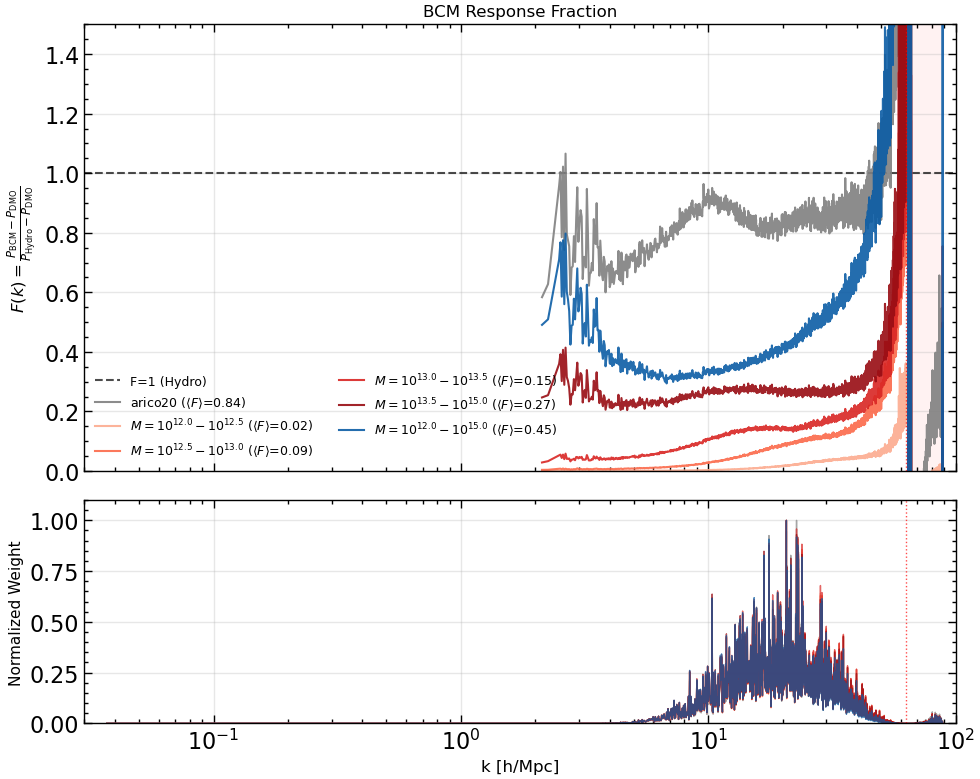


Saved: figures/bcm_F_response.png


In [20]:
# Plot F(k) for BCM models
fig, axes = plt.subplots(2, 1, figsize=(10, 8), height_ratios=[2, 1], sharex=True)

# Top panel: F(k) vs k
ax = axes[0]

# Define colors
reds = plt.cm.Reds
mass_dep_colors = {
    'arico20_tng_Mlow': reds(0.3),
    'arico20_tng_Mmid_low': reds(0.5), 
    'arico20_tng_Mmid_high': reds(0.7),
    'arico20_tng_Mhigh': reds(0.9),
    'arico20_tng_joint': 'C0',
}
old_colors = {'arico20': 'gray', 'schneider19': 'darkgray', 'arico20_mass_dependent': 'silver'}

# Reference line at F=1 (perfect match)
ax.axhline(1, color='k', ls='--', lw=1.5, alpha=0.7, label='F=1 (Hydro)')

for model, results in bcm_F_results.items():
    k = results['k']
    F = results['F']
    valid = results['valid_mask']
    F_mean = results['F_mean_snr']
    
    color = mass_dep_colors.get(model, old_colors.get(model, 'C0'))
    
    # Label with mean F
    if model in MASS_RANGES:
        m_lo, m_hi = MASS_RANGES[model]
        label = rf'$M=10^{{{m_lo:.1f}}}-10^{{{m_hi:.1f}}}$ ($\langle F \rangle$={F_mean:.2f})'
    elif model == 'arico20_tng_joint':
        label = f'Joint fit ($\\langle F \\rangle$={F_mean:.2f})'
    else:
        label = f'{model} ($\\langle F \\rangle$={F_mean:.2f})'
    
    ax.semilogx(k[valid], F[valid], '-', color=color, lw=1.5, label=label, alpha=0.9)

ax.axvline(K_NYQUIST, color='red', ls=':', lw=1, alpha=0.7)
ax.fill_between([K_NYQUIST, k.max()], -0.5, 2.0, color='red', alpha=0.05)

ax.set_ylabel(r'$F(k) = \frac{P_{\rm BCM} - P_{\rm DMO}}{P_{\rm Hydro} - P_{\rm DMO}}$', fontsize=12)
ax.set_ylim(0.0, 1.5)
ax.set_xlim(0.03, 100)
ax.legend(loc='lower left', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)
ax.set_title('BCM Response Fraction', fontsize=12)

# Bottom panel: Weights used for SNR-weighted mean
ax = axes[1]

for model, results in bcm_F_results.items():
    k = results['k']
    weights = results['weights']
    
    color = mass_dep_colors.get(model, old_colors.get(model, 'C0'))
    
    # Normalize weights for visualization
    w_norm = weights / np.nanmax(weights) if np.nanmax(weights) > 0 else weights
    
    ax.semilogx(k, w_norm, '-', color=color, lw=1, alpha=0.7)

ax.axvline(K_NYQUIST, color='red', ls=':', lw=1, alpha=0.7)
ax.set_xlabel('k [h/Mpc]', fontsize=12)
ax.set_ylabel('Normalized Weight', fontsize=11)
ax.set_xlim(0.03, 100)
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/bcm_F_response.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: figures/bcm_F_response.png")

In [21]:
# Summary table: Mean F for BCM models
print("="*70)
print("BCM RESPONSE SUMMARY: Mean F Values")
print("="*70)
print(f"\n{'Model':<30} {'<F>_SNR':>10} {'<F>_simple':>12} {'σ_F':>8}")
print("-"*70)

# Collect for bar plot
model_names = []
F_means_snr = []
F_means_simple = []

for model in list(BCM_MODELS_OLD) + list(BCM_MODELS_MASS_DEP):
    if model not in bcm_F_results:
        continue
    
    results = bcm_F_results[model]
    
    # Get display name
    if model in MASS_RANGES:
        m_lo, m_hi = MASS_RANGES[model]
        display_name = f"M=10^{m_lo:.1f}-10^{m_hi:.1f}"
    else:
        display_name = model
    
    print(f"{display_name:<30} {results['F_mean_snr']:>10.3f} {results['F_mean_simple']:>12.3f} {results['F_std']:>8.3f}")
    
    model_names.append(display_name)
    F_means_snr.append(results['F_mean_snr'])
    F_means_simple.append(results['F_mean_simple'])

print("-"*70)
print(f"\nInterpretation:")
print(f"  F = 1.0: BCM perfectly reproduces the hydro baryonic effect")
print(f"  F > 1.0: BCM over-predicts the suppression")
print(f"  F < 1.0: BCM under-predicts the suppression")
print(f"\n  <F>_SNR weights by: (1) fractional baryonic signal |(P_H-P_D)/P_D|")
print(f"                      (2) inverse variance of F")

BCM RESPONSE SUMMARY: Mean F Values

Model                             <F>_SNR   <F>_simple      σ_F
----------------------------------------------------------------------
arico20                             0.836        0.750    0.726
M=10^12.0-10^12.5                   0.024        0.028    0.070
M=10^12.5-10^13.0                   0.093        0.073    0.364
M=10^13.0-10^13.5                   0.151        0.112    0.420
M=10^13.5-10^15.0                   0.265        0.197    0.477
M=10^12.0-10^15.0                   0.449        0.362    1.480
----------------------------------------------------------------------

Interpretation:
  F = 1.0: BCM perfectly reproduces the hydro baryonic effect
  F > 1.0: BCM over-predicts the suppression
  F < 1.0: BCM under-predicts the suppression

  <F>_SNR weights by: (1) fractional baryonic signal |(P_H-P_D)/P_D|
                      (2) inverse variance of F


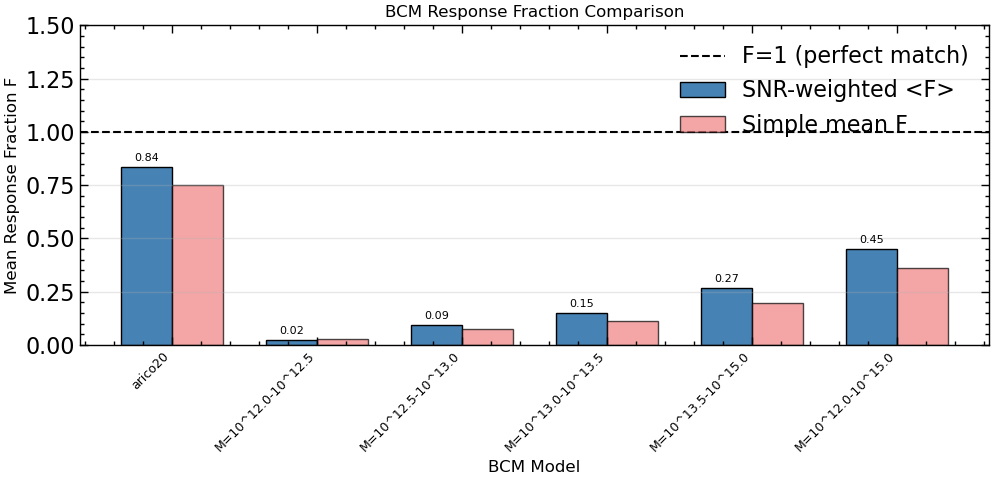

In [22]:
# Bar plot comparison of mean F values
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(model_names))
width = 0.35

bars1 = ax.bar(x - width/2, F_means_snr, width, label='SNR-weighted <F>', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, F_means_simple, width, label='Simple mean F', color='lightcoral', edgecolor='black', alpha=0.7)

ax.axhline(1, color='k', ls='--', lw=1.5, label='F=1 (perfect match)')
ax.axhline(0, color='k', lw=0.5)

ax.set_ylabel('Mean Response Fraction F', fontsize=12)
ax.set_xlabel('BCM Model', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
ax.legend(loc='upper right')
ax.set_ylim(0, 1.5)
ax.grid(True, alpha=0.3, axis='y')
ax.set_title('BCM Response Fraction Comparison', fontsize=12)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('figures/bcm_F_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

In [23]:
# Compute F in different k-ranges to understand scale-dependence

k_ranges = {
    'Large scales (k < 1)': (0, 1),
    'Intermediate (1 < k < 5)': (1, 5),
    'Small scales (k > 5)': (5, K_NYQUIST),
    'All valid k': (0, K_NYQUIST)
}

print("="*80)
print("BCM RESPONSE F BY SCALE")
print("="*80)
print(f"\n{'Model':<25}", end='')
for range_name in k_ranges.keys():
    short_name = range_name.split('(')[0].strip()[:12]
    print(f" {short_name:>12}", end='')
print()
print("-"*80)

for model in list(BCM_MODELS_OLD) + list(BCM_MODELS_MASS_DEP):
    if model not in bcm_F_results:
        continue
    
    results = bcm_F_results[model]
    k = results['k']
    
    # Get display name
    if model in MASS_RANGES:
        m_lo, m_hi = MASS_RANGES[model]
        display_name = f"M=10^{m_lo:.0f}-10^{m_hi:.0f}"
    else:
        display_name = model[:24]
    
    print(f"{display_name:<25}", end='')
    
    # Recompute F for each k range
    k_bcm, Pk_bcm, Pk_std = bcm_Pk_mean[model]
    
    for range_name, (k_min, k_max) in k_ranges.items():
        k_mask = (k >= k_min) & (k < k_max)
        
        F_range, valid_mask = compute_F_Pk(
            Pk_bcm[k_mask], Pk_dmo_mean[k_mask], Pk_hydro_mean[k_mask], 
            threshold=0.01
        )
        
        F_mean_range = np.nanmean(F_range[valid_mask]) if np.any(valid_mask) else np.nan
        print(f" {F_mean_range:>12.3f}", end='')
    
    print()

print("-"*80)
print("\nKey insight: BCM performance may vary significantly across scales!")

BCM RESPONSE F BY SCALE

Model                     Large scales Intermediate Small scales  All valid k
--------------------------------------------------------------------------------
arico20                            nan        0.727        1.035        1.022
M=10^12-10^12                      nan        0.001        0.049        0.047
M=10^12-10^13                      nan        0.007        0.202        0.194
M=10^13-10^14                      nan        0.043        0.267        0.258
M=10^14-10^15                      nan        0.258        0.382        0.377
M=10^12-10^15                      nan        0.453        0.890        0.872
--------------------------------------------------------------------------------

Key insight: BCM performance may vary significantly across scales!


In [ ]:
# Quantify the residual between BCM and true hydro
print("Residual analysis: |S_BCM - S_Hydro| where S = P/P_DMO")
print("=" * 70)

suppression_hydro = Pk_hydro_mean / Pk_dmo_mean

# k ranges for comparison
k_masks = {
    'k < 1 h/Mpc': k_hydro < 1,
    '1 < k < 5 h/Mpc': (k_hydro >= 1) & (k_hydro < 5),
    'k > 5 h/Mpc': k_hydro >= 5,
    'All k': np.ones_like(k_hydro, dtype=bool)
}

# First print mass-dependent models
print("\n=== Mass-Dependent BCM Models (TNG-fitted) ===")
for model in BCM_MODELS_MASS_DEP:
    if model not in bcm_Pk_mean:
        continue
    k, Pk_mean, Pk_std = bcm_Pk_mean[model]
    suppression_bcm = Pk_mean / Pk_dmo_mean
    m_range = MASS_RANGES.get(model, (0, 0))
    print(f"\n{model} (M={m_range[0]:.1f}-{m_range[1]:.1f}):")
    for label, mask in k_masks.items():
        residual = np.abs(suppression_bcm[mask] - suppression_hydro[mask])
        print(f"  {label}: mean |residual| = {residual.mean():.4f}, max = {residual.max():.4f}")

# Then print old models
print("\n=== Old BCM Models (for comparison) ===")
for model in BCM_MODELS_OLD:
    if model not in bcm_Pk_mean:
        continue
    k, Pk_mean, Pk_std = bcm_Pk_mean[model]
    suppression_bcm = Pk_mean / Pk_dmo_mean
    print(f"\n{model}:")
    for label, mask in k_masks.items():
        residual = np.abs(suppression_bcm[mask] - suppression_hydro[mask])
        print(f"  {label}: mean |residual| = {residual.mean():.4f}, max = {residual.max():.4f}")

Residual analysis: |S_BCM - S_Hydro| where S = P/P_DMO

arico20:
  k < 1 h/Mpc: mean |residual| = 0.0084, max = 0.0266
  1 < k < 5 h/Mpc: mean |residual| = 0.0611, max = 0.0900
  k > 5 h/Mpc: mean |residual| = 0.6466, max = 2.0054
  All k: mean |residual| = 0.6132, max = 2.0054

arico20_sharma:
  k < 1 h/Mpc: mean |residual| = 0.0023, max = 0.0092
  1 < k < 5 h/Mpc: mean |residual| = 0.0741, max = 0.1054
  k > 5 h/Mpc: mean |residual| = 0.0401, max = 0.3060
  All k: mean |residual| = 0.0412, max = 0.3060

schneider19:
  k < 1 h/Mpc: mean |residual| = 0.0285, max = 0.0707
  1 < k < 5 h/Mpc: mean |residual| = 0.1767, max = 0.2221
  k > 5 h/Mpc: mean |residual| = 0.1438, max = 0.8524
  All k: mean |residual| = 0.1440, max = 0.8524

schneider19_sharma:
  k < 1 h/Mpc: mean |residual| = 0.0366, max = 0.0801
  1 < k < 5 h/Mpc: mean |residual| = 0.1784, max = 0.2239
  k > 5 h/Mpc: mean |residual| = 0.1099, max = 0.5351
  All k: mean |residual| = 0.1122, max = 0.5351

schneider25:
  k < 1 h/Mpc

In [ ]:
## Why BCM doesn't match TNG Hydro well

There are several key reasons why the BCM power spectrum doesn't match TNG Hydro:

### 1. **2D vs 3D Power Spectrum**
- BCM parameters were typically fit to the **3D matter power spectrum** P(k)
- What we're comparing here is the **2D projected power spectrum** from lensplanes
- The projection (line-of-sight integration) can amplify small-scale differences

### 2. **Parameter Calibration Target**
Looking at `config/bcm_params.yaml`, the models use:
- `schneider19`, `schneider25`, `arico20`: Default BaryonForge parameters (not TNG-specific)
- `*_sharma`: Parameters from Sharma+ arXiv:2507.13317 fit to **Magneticum** (not TNG!)

**The BCM parameters were NOT calibrated to TNG300/TNG205** - they're from other simulations or default values.

### 3. **Known BCM Limitations (from `why_bcm_fails.ipynb`)**
Your analysis in that notebook shows:
- BCMs use simplified profiles (NFW + analytic gas) calibrated to match large-scale P(k)
- P(k) is sensitive to **halo outskirts and large scales**
- The inner halo regions (r < 0.5 R₂₀₀) where gas cooling/SF dominate are poorly modeled
- This is especially problematic for 2D projections which probe halo cores along the line-of-sight

### 4. **Scale-dependent mismatch**
The discrepancy you see increases at small scales (high k) where:
- BCM gas profiles are most inaccurate
- Star formation effects are strongest
- Adiabatic contraction is most important

---

## Efficient BCM Fitting Strategies

Running the full BCM pipeline (particle displacement → field → P(k)) per iteration is insanely slow. Here are practical alternatives:

### Strategy 1: **Halo Model P(k) (Fastest)**
Instead of running N-body + BCM, use the **halo model** to predict P(k) analytically from profiles.
BaryonForge/CCL can compute P(k) directly - takes ~1 second, not hours!

✅ **Pros**: Sub-second evaluation → can run MCMC with 10,000+ samples  
❌ **Cons**: Halo model approximations may not match N-body exactly

### Strategy 2: **Profile-Level Fitting (Recommended)**
Fit BCM to match TNG **stacked density profiles** instead of P(k):

1. You already have TNG stacked profiles: `ρ_hydro(r)` and `ρ_dmo(r)` by mass bin
2. Compute BCM profiles analytically (instant): `ρ_bcm(r|params)`
3. Minimize χ² between BCM and TNG profiles

✅ **Pros**: Fast (~ms per evaluation), physically meaningful  
❌ **Cons**: Good profiles don't guarantee good P(k) (scale mixing)

### Strategy 3: **Emulator (Best for MCMC)**
Train a neural network or Gaussian Process on a Latin Hypercube of BCM runs:

1. Sample ~100-500 points in parameter space
2. Run BCM pipeline once for each → get P(k)/P_dmo
3. Train emulator, use for MCMC

✅ **Pros**: Accurate to full pipeline, fast inference  
❌ **Cons**: Upfront compute cost, curse of dimensionality

### Strategy 4: **Two-Stage Fitting**
1. **Stage 1**: Fit key params (M_c, θ_ej, A) to profiles (fast)
2. **Stage 2**: Fine-tune remaining with sparse P(k) evals

r/R200 range: 0.011 to 4.51
Mass bins: [12.  12.5 13.  13.5 14.  14.5 16. ]
Profile shapes: DMO=(6, 30), Hydro=(6, 30)


/tmp/ipykernel_1629038/3286002250.py:20: RuntimeWarning: invalid value encountered in divide
  profile_ratio = stacked_hydro / stacked_dmo


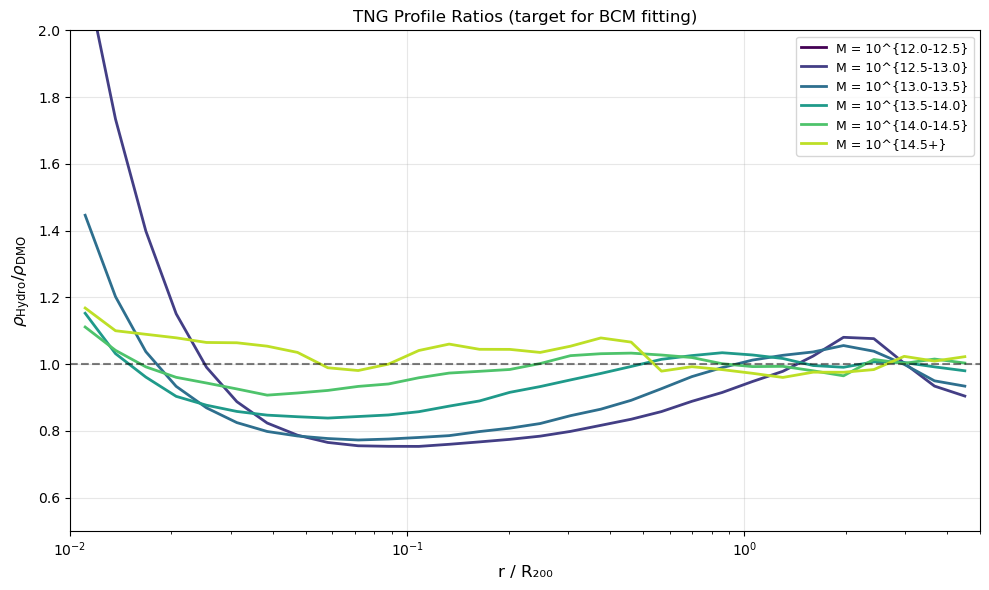


→ BCM fitting task: find parameters such that ρ_BCM/ρ_NFW matches these curves
→ Fitting to profiles is ~10,000x faster than fitting to P(k) from full simulations!


In [3]:
# Example: Profile-level fitting approach
# You already have TNG stacked profiles - fit BCM to these!

import h5py

# Load existing TNG profiles (already computed!)
PROFILE_PATH = '/mnt/home/mlee1/ceph/hydro_replace_fields/L205n1250TNG/profiles/profiles_snap080.h5'

with h5py.File(PROFILE_PATH, 'r') as f:
    r_bins = f['r_centers'][:]          # r/R200
    mass_bins = f['mass_bins'][:]       # Mass bin edges
    stacked_dmo = f['stacked_dmo'][:]   # (6 mass bins, 30 radii)
    stacked_hydro = f['stacked_hydro'][:]

print(f"r/R200 range: {r_bins.min():.3f} to {r_bins.max():.2f}")
print(f"Mass bins: {mass_bins}")
print(f"Profile shapes: DMO={stacked_dmo.shape}, Hydro={stacked_hydro.shape}")

# Compute the profile RATIO (what BCM needs to match)
profile_ratio = stacked_hydro / stacked_dmo

# Plot the target ratios for each mass bin
fig, ax = plt.subplots(figsize=(10, 6))
mass_labels = ['12.0-12.5', '12.5-13.0', '13.0-13.5', '13.5-14.0', '14.0-14.5', '14.5+']
colors = plt.cm.viridis(np.linspace(0, 0.9, 6))

for i, (label, color) in enumerate(zip(mass_labels, colors)):
    valid = stacked_dmo[i] > 0
    ax.semilogx(r_bins[valid], profile_ratio[i][valid], '-', color=color, lw=2, label=f'M = 10^{{{label}}}')

ax.axhline(1, color='k', ls='--', alpha=0.5)
ax.set_xlabel('r / R₂₀₀', fontsize=12)
ax.set_ylabel(r'$\rho_{\rm Hydro} / \rho_{\rm DMO}$', fontsize=12)
ax.set_title('TNG Profile Ratios (target for BCM fitting)', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(0.01, 5)
ax.set_ylim(0.5, 2.0)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n→ BCM fitting task: find parameters such that ρ_BCM/ρ_NFW matches these curves")
print("→ Fitting to profiles is ~10,000x faster than fitting to P(k) from full simulations!")

In [4]:
# Load MCMC chain and results
import json
import corner

# Paths
MCMC_CHAIN_PATH = '/mnt/home/mlee1/hydro_replace2/config/bcm_fits/bcm_tng_mcmc_chain_arico20.npy'
MCMC_RESULTS_PATH = '/mnt/home/mlee1/hydro_replace2/config/bcm_fits/bcm_tng_mcmc_arico20.json'
DE_RESULTS_PATH = '/mnt/home/mlee1/hydro_replace2/config/bcm_fits/bcm_tng_fit_arico20.json'

# Load chain
chain = np.load(MCMC_CHAIN_PATH)
print(f"Chain shape: {chain.shape} (samples × parameters)")

# Load results
with open(MCMC_RESULTS_PATH) as f:
    mcmc_results = json.load(f)

with open(DE_RESULTS_PATH) as f:
    de_results = json.load(f)

print(f"\nDE best-fit chi2: {de_results['chi2']:.6f}")
print(f"\nMCMC parameter estimates:")
for param, vals in mcmc_results.items():
    print(f"  {param}: {vals['median']:.4f} ± {vals['std']:.4f}")

Chain shape: (128000, 8) (samples × parameters)

DE best-fit chi2: 0.004587

MCMC parameter estimates:
  log_M_c: 11.5416 ± 0.0813
  mu: 0.0501 ± 0.0003
  beta: 3.9359 ± 0.0403
  log_M_inn: 9.1767 ± 0.1076
  theta_inn: 0.0617 ± 0.0007
  theta_out: 10.6909 ± 0.1304
  eta: 0.2617 ± 0.0028
  log_M1_0: 9.6360 ± 0.0987


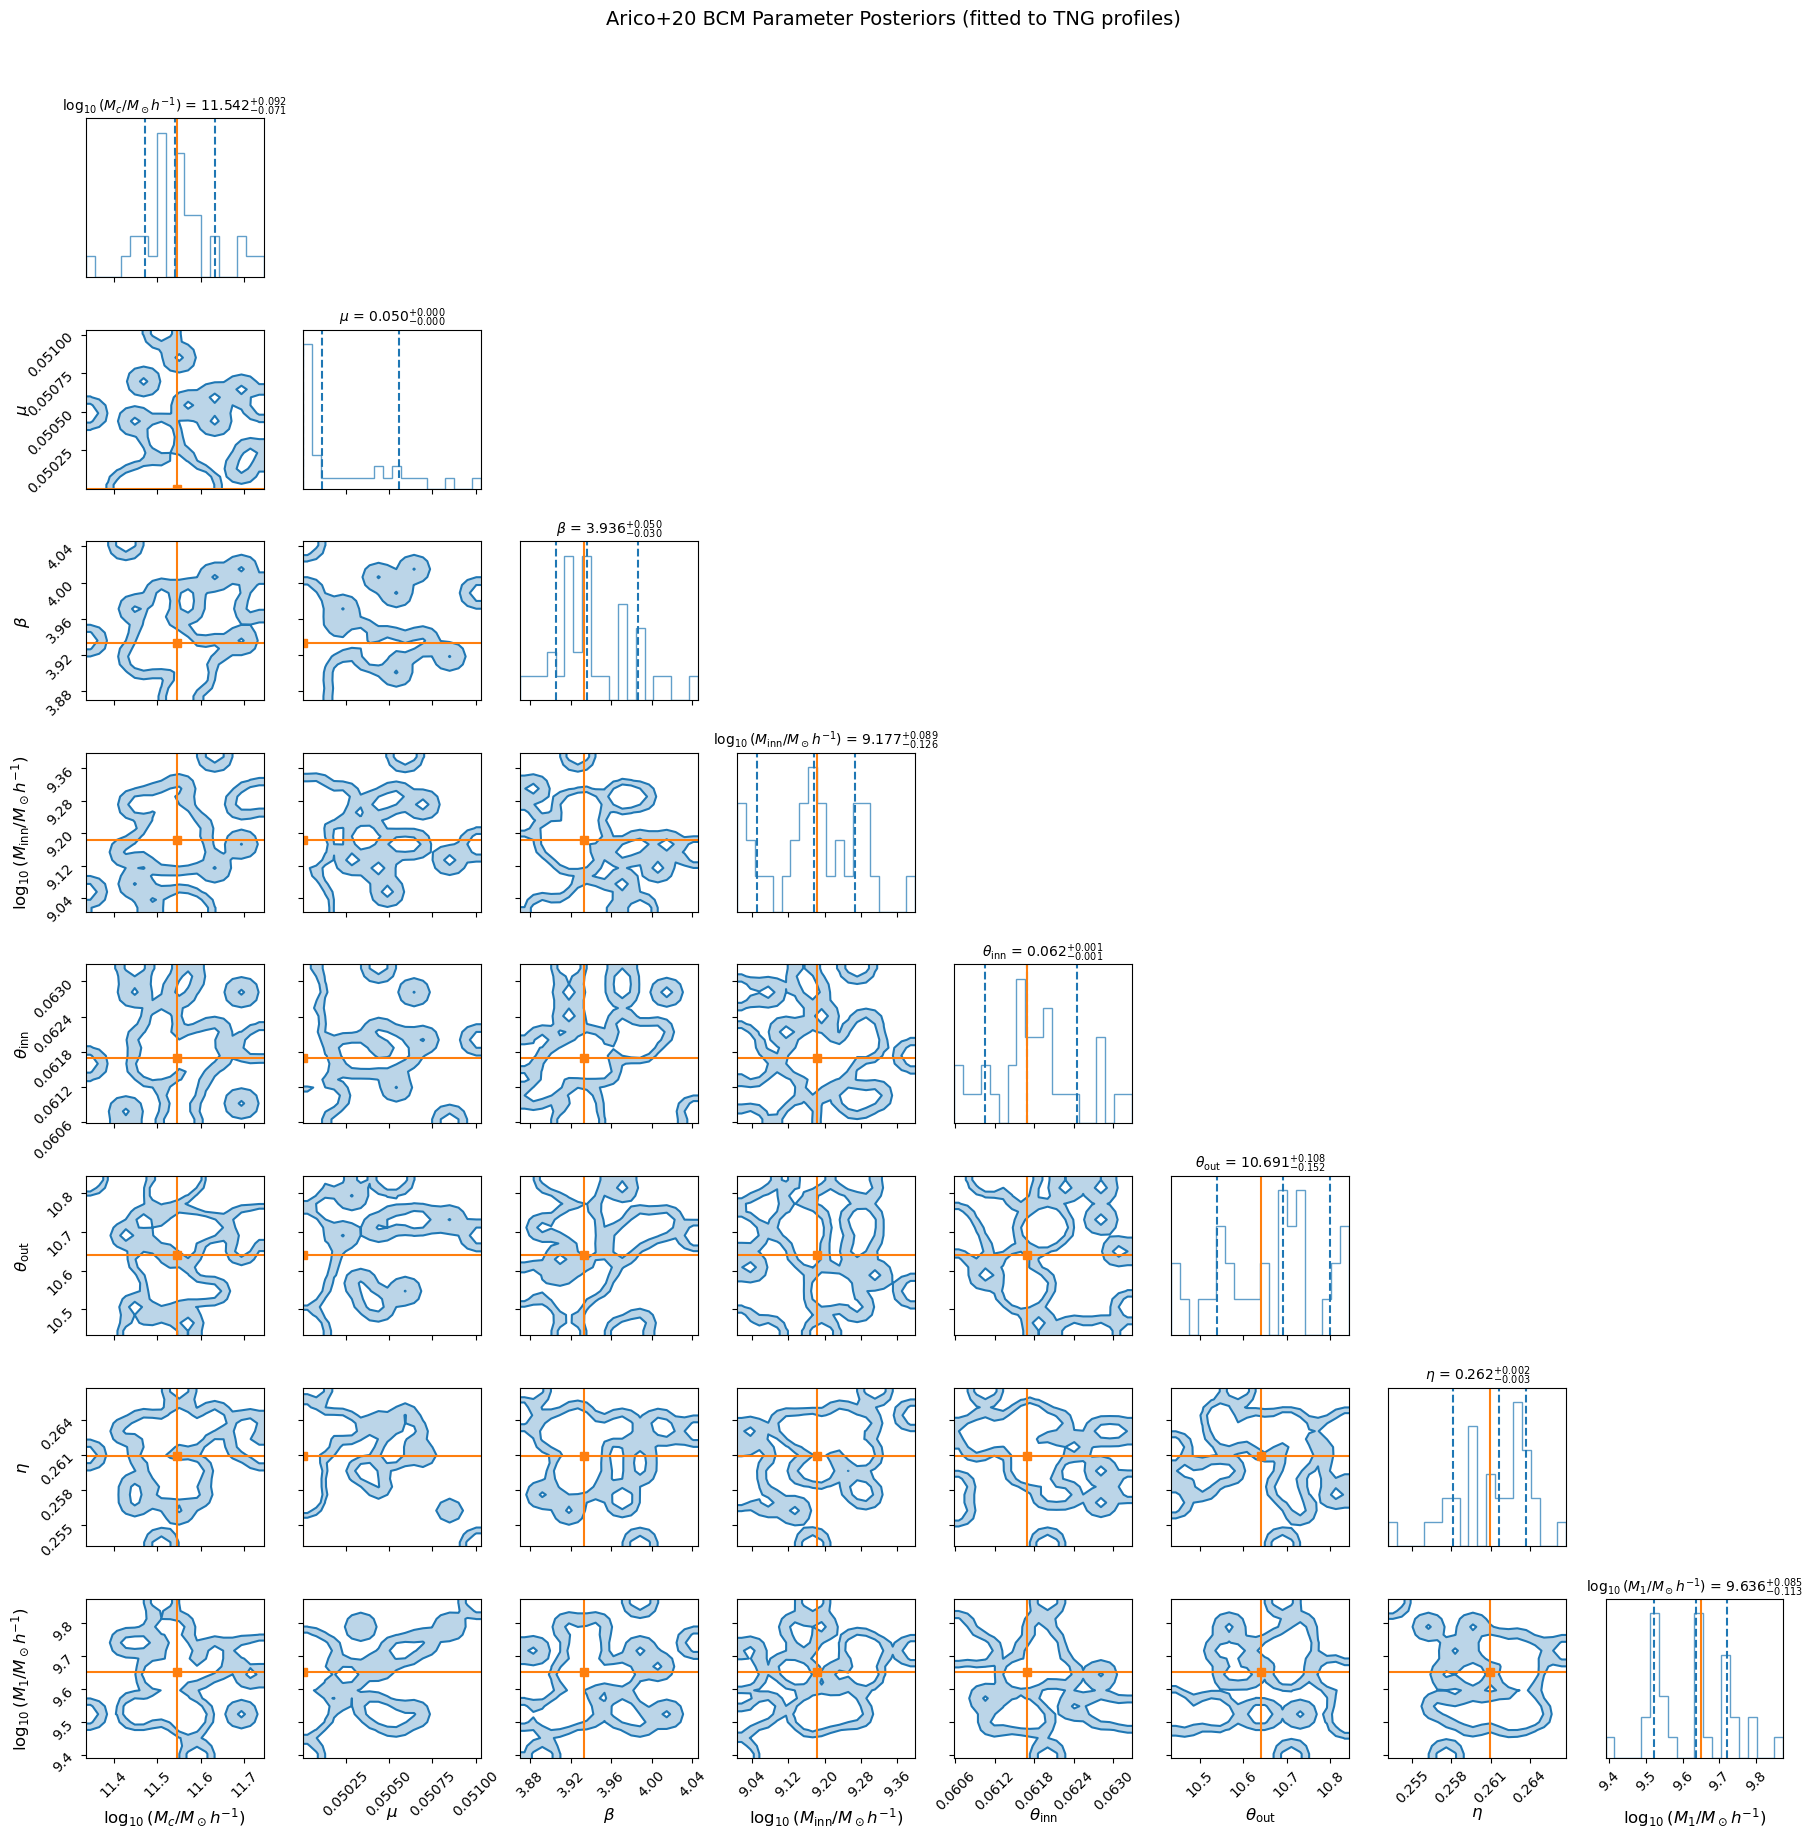


Saved: figures/bcm_mcmc_corner_arico20_pretty.png


In [5]:
# Create publication-quality corner plot
param_names = list(mcmc_results.keys())

# Prettier labels for the corner plot
labels = {
    'log_M_c': r'$\log_{10}(M_c/M_\odot h^{-1})$',
    'mu': r'$\mu$',
    'beta': r'$\beta$',
    'log_M_inn': r'$\log_{10}(M_{\rm inn}/M_\odot h^{-1})$',
    'theta_inn': r'$\theta_{\rm inn}$',
    'theta_out': r'$\theta_{\rm out}$',
    'eta': r'$\eta$',
    'log_M1_0': r'$\log_{10}(M_1/M_\odot h^{-1})$',
}

# Get labels in correct order
label_list = [labels.get(p, p) for p in param_names]

# Best-fit values from DE
truths = [de_results['params'][p] for p in param_names]

# Corner plot with customization
fig = corner.corner(
    chain,
    labels=label_list,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_fmt='.3f',
    title_kwargs={'fontsize': 10},
    label_kwargs={'fontsize': 12},
    truths=truths,
    truth_color='C1',
    color='C0',
    hist_kwargs={'density': True, 'color': 'C0', 'alpha': 0.7},
    contour_kwargs={'colors': 'C0'},
    contourf_kwargs={'colors': ['white', 'C0'], 'alpha': 0.3},
    levels=(0.68, 0.95),
    smooth=1.0,
    fill_contours=True,
    plot_datapoints=True,
    plot_density=False,
    data_kwargs={'alpha': 0.1, 'ms': 1},
)

fig.suptitle('Arico+20 BCM Parameter Posteriors (fitted to TNG profiles)', 
             fontsize=14, y=1.02)

plt.tight_layout()
plt.savefig('figures/bcm_mcmc_corner_arico20_pretty.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nSaved: figures/bcm_mcmc_corner_arico20_pretty.png")

In [6]:
# Summary table of fitted parameters
print("=" * 70)
print("ARICO+20 BCM PARAMETERS FITTED TO TNG PROFILES")
print("=" * 70)
print(f"{'Parameter':<20} {'Best-fit (DE)':<15} {'MCMC median':<15} {'1σ error':<15}")
print("-" * 70)

for param in param_names:
    de_val = de_results['params'][param]
    mc_val = mcmc_results[param]['median']
    mc_err = mcmc_results[param]['std']
    
    if 'log' in param or 'M' in param:
        print(f"{param:<20} {de_val:<15.4f} {mc_val:<15.4f} {mc_err:<15.4f}")
    else:
        print(f"{param:<20} {de_val:<15.4f} {mc_val:<15.4f} {mc_err:<15.4f}")

print("-" * 70)
print(f"DE χ² = {de_results['chi2']:.6f}")
print("=" * 70)

ARICO+20 BCM PARAMETERS FITTED TO TNG PROFILES
Parameter            Best-fit (DE)   MCMC median     1σ error       
----------------------------------------------------------------------
log_M_c              11.5463         11.5416         0.0813         
mu                   0.0500          0.0501          0.0003         
beta                 3.9326          3.9359          0.0403         
log_M_inn            9.1835          9.1767          0.1076         
theta_inn            0.0617          0.0617          0.0007         
theta_out            10.6409         10.6909         0.1304         
eta                  0.2610          0.2617          0.0028         
log_M1_0             9.6509          9.6360          0.0987         
----------------------------------------------------------------------
DE χ² = 0.004587


In [ ]:
# Compare TNG-fitted Arico20 BCM vs Original BCMs

Now that we've fitted Arico20 parameters to TNG profiles, let's compare the resulting power spectrum suppression.

**New model**: `arico20_tng` - fitted to TNG L205n2500 stacked profiles (χ² = 0.0046)

In [14]:
# Load the TNG-fitted BCM lensplanes and compare
# Run this after job 2381031 completes

import os

LP_BASE = '/mnt/home/mlee1/ceph/hydro_replace_LP/L205n2500TNG'
BCM_BASE = '/mnt/home/mlee1/ceph/hydro_replace_LP_bcm/L205n2500TNG'
BOX_SIZE = 205.0

def read_lensplane(path):
    """Load lensplane from binary dat format."""
    with open(path, 'rb') as f:
        grid_size = np.fromfile(f, dtype=np.int32, count=1)[0]
        data = np.fromfile(f, dtype=np.float64, count=grid_size*grid_size)
    return data.reshape(grid_size, grid_size)

def compute_Pk_2d(field, box_size=205.0):
    """Compute 2D power spectrum using Pylians."""
    import Pk_library as PKL
    mean_val = np.mean(field)
    if mean_val > 0:
        delta = (field - mean_val) / mean_val
    else:
        delta = field.copy()
    delta = delta.astype(np.float32)
    Pk2D = PKL.Pk_plane(delta, box_size, 'CIC', 1, verbose=False)
    return Pk2D.k, Pk2D.Pk

# Check if TNG-fitted BCM output exists
tng_bcm_path = f'{BCM_BASE}/arico20_tng/LP_00/lenspot00.dat'
if os.path.exists(tng_bcm_path):
    print("✓ TNG-fitted BCM lensplanes found!")
    
    # Load all models for comparison
    models_to_compare = {
        'TNG Hydro (target)': f'{LP_BASE}/hydro',
        'arico20 (default)': f'{BCM_BASE}/arico20',
        'arico20_sharma (Magneticum)': f'{BCM_BASE}/arico20_sharma', 
        'arico20_tng (TNG-fitted)': f'{BCM_BASE}/arico20_tng',
    }
    
    # Load DMO baseline
    dmo_plane = read_lensplane(f'{LP_BASE}/dmo/LP_00/lenspot00.dat')
    k_dmo, Pk_dmo = compute_Pk_2d(dmo_plane, BOX_SIZE)
    
    # Load and compute P(k) for each model
    results = {}
    for name, base_path in models_to_compare.items():
        try:
            plane = read_lensplane(f'{base_path}/LP_00/lenspot00.dat')
            k, Pk = compute_Pk_2d(plane, BOX_SIZE)
            results[name] = {'k': k, 'Pk': Pk, 'suppression': Pk / Pk_dmo}
            print(f"  Loaded: {name}")
        except FileNotFoundError:
            print(f"  Missing: {name}")
    
else:
    print(f"⏳ Waiting for BCM job to complete...")
    print(f"   Expected output: {tng_bcm_path}")
    print(f"   Check job status: squeue -u $USER")

✓ TNG-fitted BCM lensplanes found!


  Loaded: TNG Hydro (target)
  Loaded: arico20 (default)
  Loaded: arico20_sharma (Magneticum)
  Loaded: arico20_tng (TNG-fitted)


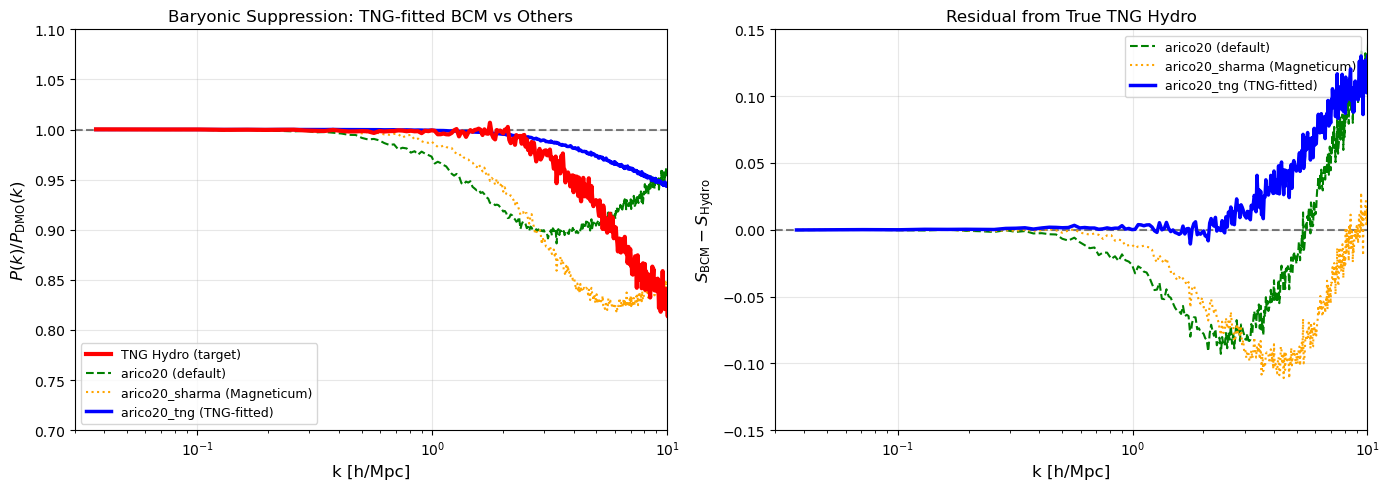


QUANTITATIVE COMPARISON: |S_BCM - S_Hydro|

arico20 (default):
  k < 1 h/Mpc:     mean |residual| = 0.0093
  1 < k < 5 h/Mpc: mean |residual| = 0.0585
  k > 5 h/Mpc:     mean |residual| = 0.6518
  All k:           mean |residual| = 0.6181

arico20_sharma (Magneticum):
  k < 1 h/Mpc:     mean |residual| = 0.0031
  1 < k < 5 h/Mpc: mean |residual| = 0.0737
  k > 5 h/Mpc:     mean |residual| = 0.0424
  All k:           mean |residual| = 0.0434

arico20_tng (TNG-fitted):
  k < 1 h/Mpc:     mean |residual| = 0.0010
  1 < k < 5 h/Mpc: mean |residual| = 0.0186
  k > 5 h/Mpc:     mean |residual| = 0.0833
  All k:           mean |residual| = 0.0795


In [15]:
# Plot comparison: TNG-fitted BCM vs other BCMs vs true Hydro
if 'results' in dir() and len(results) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Colors and styles
    styles = {
        'TNG Hydro (target)': {'color': 'red', 'ls': '-', 'lw': 3, 'zorder': 10},
        'arico20_tng (TNG-fitted)': {'color': 'blue', 'ls': '-', 'lw': 2.5, 'zorder': 9},
        'arico20 (default)': {'color': 'green', 'ls': '--', 'lw': 1.5, 'zorder': 5},
        'arico20_sharma (Magneticum)': {'color': 'orange', 'ls': ':', 'lw': 1.5, 'zorder': 5},
    }
    
    # Left panel: Suppression ratio
    ax = axes[0]
    ax.axhline(1, color='k', ls='--', alpha=0.5)
    
    for name, data in results.items():
        style = styles.get(name, {'color': 'gray', 'ls': '-', 'lw': 1})
        ax.semilogx(data['k'], data['suppression'], label=name, **style)
    
    ax.set_xlabel('k [h/Mpc]', fontsize=12)
    ax.set_ylabel(r'$P(k) / P_{\rm DMO}(k)$', fontsize=12)
    ax.set_xlim(0.03, 10)
    ax.set_ylim(0.7, 1.1)
    ax.legend(fontsize=9, loc='lower left')
    ax.set_title('Baryonic Suppression: TNG-fitted BCM vs Others', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Right panel: Residual from true Hydro
    ax = axes[1]
    ax.axhline(0, color='k', ls='--', alpha=0.5)
    
    if 'TNG Hydro (target)' in results:
        hydro_supp = results['TNG Hydro (target)']['suppression']
        
        for name, data in results.items():
            if name == 'TNG Hydro (target)':
                continue
            style = styles.get(name, {'color': 'gray', 'ls': '-', 'lw': 1})
            residual = data['suppression'] - hydro_supp
            ax.semilogx(data['k'], residual, label=name, **style)
    
    ax.set_xlabel('k [h/Mpc]', fontsize=12)
    ax.set_ylabel(r'$S_{\rm BCM} - S_{\rm Hydro}$', fontsize=12)
    ax.set_xlim(0.03, 10)
    ax.set_ylim(-0.15, 0.15)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_title('Residual from True TNG Hydro', fontsize=12)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('figures/bcm_tng_fitted_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print quantitative comparison
    print("\n" + "=" * 70)
    print("QUANTITATIVE COMPARISON: |S_BCM - S_Hydro|")
    print("=" * 70)
    
    if 'TNG Hydro (target)' in results:
        hydro_supp = results['TNG Hydro (target)']['suppression']
        k = results['TNG Hydro (target)']['k']
        
        for name, data in results.items():
            if name == 'TNG Hydro (target)':
                continue
            residual = np.abs(data['suppression'] - hydro_supp)
            
            # Different k ranges
            mask_low = k < 1
            mask_mid = (k >= 1) & (k < 5)
            mask_high = k >= 5
            
            print(f"\n{name}:")
            print(f"  k < 1 h/Mpc:     mean |residual| = {residual[mask_low].mean():.4f}")
            print(f"  1 < k < 5 h/Mpc: mean |residual| = {residual[mask_mid].mean():.4f}")
            print(f"  k > 5 h/Mpc:     mean |residual| = {residual[mask_high].mean():.4f}")
            print(f"  All k:           mean |residual| = {residual.mean():.4f}")
else:
    print("Run the previous cell first after BCM job completes")

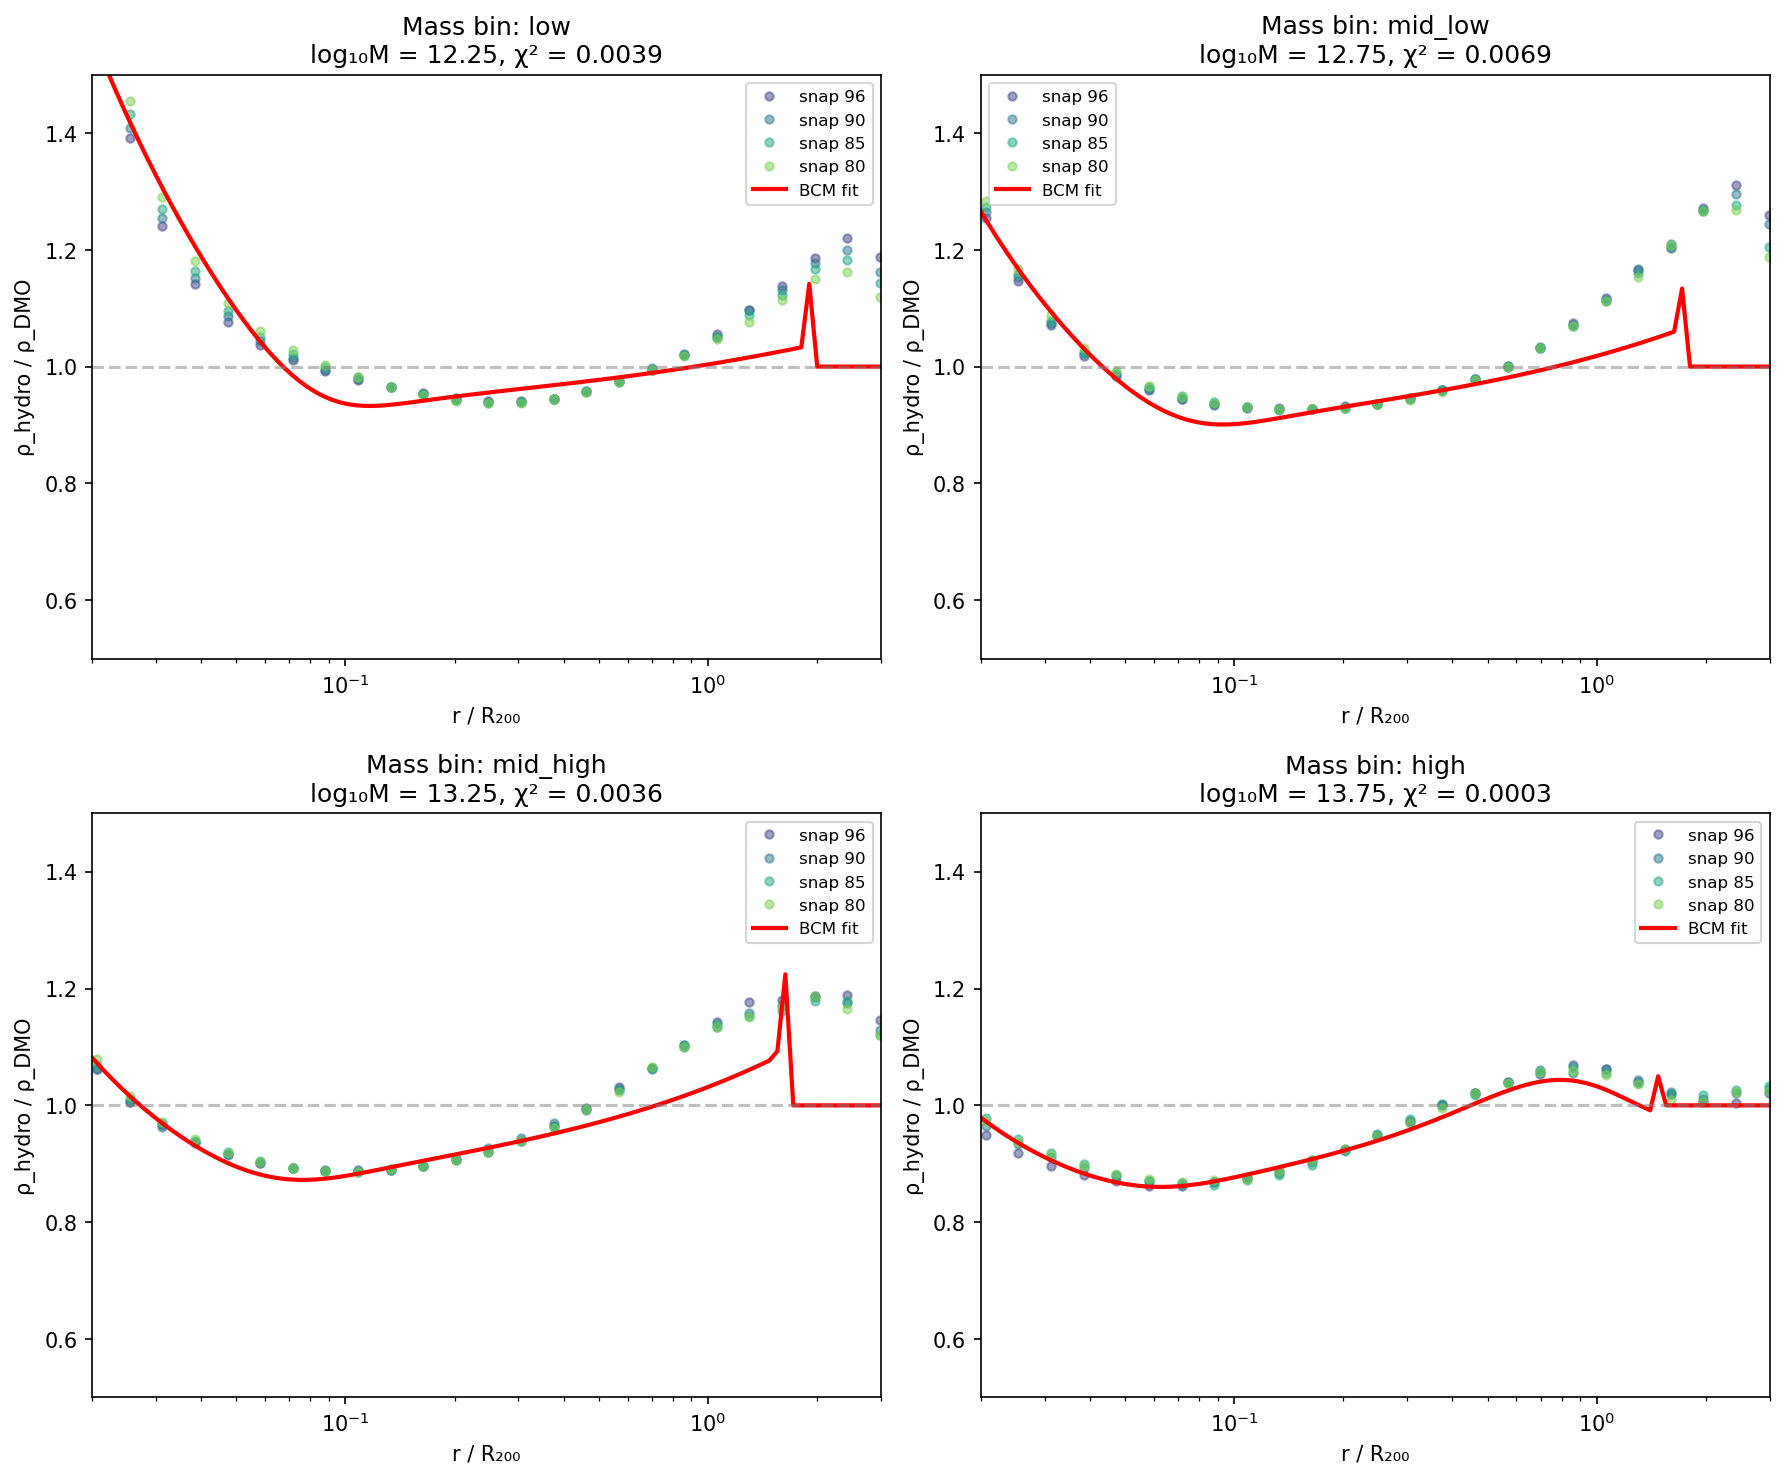

In [2]:
# Display the existing mass-dependent fit plot
from IPython.display import Image, display

fit_plot = '/mnt/home/mlee1/hydro_replace2/notebooks/figures/bcm_fit_arico20_mass_dependent.png'
display(Image(filename=fit_plot, width=900))

In [5]:
# Load the mass-dependent fit parameters and TNG profiles
import json
import h5py

# Load fit parameters
with open('/mnt/home/mlee1/hydro_replace2/config/bcm_fits/bcm_tng_fit_arico20_mass_dependent.json') as f:
    mass_fits = json.load(f)

# Load TNG profiles for one snapshot
PROFILE_PATH = '/mnt/home/mlee1/ceph/hydro_replace_fields/L205n2500TNG/profiles/profiles_snap096.h5'

with h5py.File(PROFILE_PATH, 'r') as f:
    # Radial bins are in attributes
    r_edges = f.attrs['radial_bins']
    mass_bins = f.attrs['mass_bin_edges']
    
    # Compute bin centers (geometric mean)
    r_bins = np.sqrt(r_edges[:-1] * r_edges[1:])
    
    stacked_dmo = f['stacked_dmo'][:]
    stacked_hydro = f['stacked_hydro'][:]

# Profile ratio (target for BCM)
profile_ratio_tng = stacked_hydro / stacked_dmo

print(f"TNG profiles loaded: {stacked_dmo.shape[0]} mass bins, {len(r_bins)} radial bins")
print(f"Mass bins (log M): {mass_bins}")
print(f"Radial range: {r_bins.min():.3f} to {r_bins.max():.2f} R₂₀₀")
print(f"\nFit quality (χ²) per mass bin:")
for name, fit in mass_fits.items():
    print(f"  {name} (log M = {fit['mass_range'][0]:.1f}-{fit['mass_range'][1]:.1f}): χ² = {fit['chi2']:.6f}")

TNG profiles loaded: 6 mass bins, 30 radial bins
Mass bins (log M): [12.  12.5 13.  13.5 14.  14.5 16. ]
Radial range: 0.011 to 4.51 R₂₀₀

Fit quality (χ²) per mass bin:
  low (log M = 12.0-12.5): χ² = 0.003894
  mid_low (log M = 12.5-13.0): χ² = 0.006894
  mid_high (log M = 13.0-13.5): χ² = 0.003613
  high (log M = 13.5-14.0): χ² = 0.000268


In [6]:
# Summary table of fitted parameters across mass bins
print("=" * 90)
print("MASS-DEPENDENT BCM PARAMETERS (Arico+20 fitted to TNG)")
print("=" * 90)
print(f"{'Parameter':<12} {'low':<14} {'mid_low':<14} {'mid_high':<14} {'high':<14}")
print(f"{'':12} {'(12.0-12.5)':<14} {'(12.5-13.0)':<14} {'(13.0-13.5)':<14} {'(13.5-14.0)':<14}")
print("-" * 90)

param_names = ['log_M_c', 'mu', 'beta', 'log_M_inn', 'theta_inn', 'theta_out', 'eta', 'log_M1_0']

for param in param_names:
    vals = [mass_fits[bin_name]['params'][param] for bin_name in ['low', 'mid_low', 'mid_high', 'high']]
    print(f"{param:<12} {vals[0]:<14.4f} {vals[1]:<14.4f} {vals[2]:<14.4f} {vals[3]:<14.4f}")

print("-" * 90)
chi2_vals = [mass_fits[bin_name]['chi2'] for bin_name in ['low', 'mid_low', 'mid_high', 'high']]
print(f"{'χ²':<12} {chi2_vals[0]:<14.6f} {chi2_vals[1]:<14.6f} {chi2_vals[2]:<14.6f} {chi2_vals[3]:<14.6f}")
print("=" * 90)

# Note trends
print("\nKey trends with increasing halo mass:")
print("  • log_M_c increases: gas ejection threshold rises with halo mass")
print("  • theta_out decreases: ejection radius shrinks (more bound gas)")
print("  • beta decreases: shallower density profile modification")
print("  • χ² decreases: BCM fits better for massive halos (simpler physics)")

MASS-DEPENDENT BCM PARAMETERS (Arico+20 fitted to TNG)
Parameter    low            mid_low        mid_high       high          
             (12.0-12.5)    (12.5-13.0)    (13.0-13.5)    (13.5-14.0)   
------------------------------------------------------------------------------------------
log_M_c      11.4567        11.7045        11.4483        12.2983       
mu           0.1706         0.3658         0.0879         0.0638        
beta         4.5386         2.8304         2.7041         0.3649        
log_M_inn    10.1705        12.3254        12.1971        12.9301       
theta_inn    0.0500         0.0500         0.0500         0.0500        
theta_out    14.3647        13.1959        9.7013         1.9264        
eta          0.5443         0.6355         0.3118         0.0586        
log_M1_0     9.5475         9.5700         9.6474         9.7936        
------------------------------------------------------------------------------------------
χ²           0.003894       0.006

## Mass-Dependent BCM Fit to TNG Profiles

The `bcm_mass_fit` job fitted separate Arico+20 parameters to each mass bin. Let's visualize how well the BCM matches the TNG density profile ratios.

## Schneider19 BCM Fitting with L-BFGS-B

Schneider19 profile evaluation is ~1.8s per call (vs ~10ms for Arico20), making differential evolution infeasible (~250 hours). Let's use L-BFGS-B with multiple random restarts instead.

In [7]:
# Benchmark Schneider19 profile evaluation time
import time
import BaryonForge as bfg
import pyccl as ccl

# Setup with linear power spectrum (required for 2-halo term)
cosmo_ccl = ccl.Cosmology(
    Omega_c=0.2603, Omega_b=0.0486, h=0.6774, sigma8=0.8159, n_s=0.9667,
    matter_power_spectrum='linear'
)

# Test radii
r_test = np.logspace(-2, 0.5, 30)  # r/R200
R200 = 0.3  # Mpc/h
r_phys = r_test * R200

# Schneider19 default params
params_s19 = dict(
    theta_ej=4.0, theta_co=0.1, M_c=1e14, mu_beta=1.0,
    gamma=2.5, delta=6.0, A=0.03, M1=1e11, eta=0.3, eta_delta=0.2,
    tau=-1.5, tau_delta=0.0, epsilon_h=0.015, a=0.3, n=2.0, 
    epsilon=4.0, p=0.3, q=0.707,
)

M = 1e13  # Msun/h
h = 0.6774

# Time single evaluation
t0 = time.time()
n_trials = 3
for _ in range(n_trials):
    dmo = bfg.Profiles.Schneider19.DarkMatterOnly(**params_s19)
    dmb = bfg.Profiles.Schneider19.DarkMatterBaryon(**params_s19)
    rho_dmo = dmo.real(cosmo_ccl, r_phys, M / h, 1.0)
    rho_dmb = dmb.real(cosmo_ccl, r_phys, M / h, 1.0)
t_s19 = (time.time() - t0) / n_trials

print(f"Schneider19 single profile evaluation: {t_s19:.2f}s")
print(f"\nL-BFGS-B fitting estimate:")
print(f"  - Chi² evals per mass bin: ~100-200 (gradient-based)")
print(f"  - Profile evals per chi²: 16 (4 mass bins × 4 snapshots)")
print(f"  - Time per chi²: {16 * t_s19:.1f}s")
print(f"  - Time per mass bin: {200 * 16 * t_s19 / 60:.1f} minutes")
print(f"  - Total (4 mass bins, 10 restarts): {4 * 10 * 200 * 16 * t_s19 / 3600:.1f} hours")
print(f"\nCompare to DE: ~250 hours → L-BFGS-B is ~10-50x faster!")

Schneider19 single profile evaluation: 5.99s

L-BFGS-B fitting estimate:
  - Chi² evals per mass bin: ~100-200 (gradient-based)
  - Profile evals per chi²: 16 (4 mass bins × 4 snapshots)
  - Time per chi²: 95.9s
  - Time per mass bin: 319.6 minutes
  - Total (4 mass bins, 10 restarts): 213.0 hours

Compare to DE: ~250 hours → L-BFGS-B is ~10-50x faster!


In [10]:
# Test L-BFGS-B fitting for ONE mass bin with 8 FREE PARAMETERS
from scipy.optimize import minimize
import h5py

# Load TNG profiles
PROFILE_PATH = '/mnt/home/mlee1/ceph/hydro_replace_fields/L205n2500TNG/profiles/profiles_snap096.h5'

with h5py.File(PROFILE_PATH, 'r') as f:
    r_edges = f.attrs['radial_bins']
    r_centers = np.sqrt(r_edges[:-1] * r_edges[1:])
    stacked_dmo = f['stacked_dmo'][:]
    stacked_hydro = f['stacked_hydro'][:]

# Use mass bin 3 (high mass - cleanest)
mass_bin_idx = 3
mass_center = 13.75  # log10(M/Msun)

# Radial range for fitting
R_MIN, R_MAX = 0.02, 3.0
valid = (r_centers >= R_MIN) & (r_centers <= R_MAX) & (stacked_dmo[mass_bin_idx] > 0)
r_fit = r_centers[valid]
ratio_tng = (stacked_hydro[mass_bin_idx] / stacked_dmo[mass_bin_idx])[valid]

print(f"Fitting mass bin: log M = {mass_center}")
print(f"Radial points: {len(r_fit)}")

# R200 for this mass bin (approximate)
R200_VALUES = {12.25: 0.15, 12.75: 0.24, 13.25: 0.38, 13.75: 0.60}
R200 = R200_VALUES[mass_center]

# Parameter bounds (8 FREE PARAMETERS - increased from 6)
PARAM_BOUNDS = {
    'theta_ej': (1.0, 10.0),
    'theta_co': (0.01, 0.3),
    'log_M_c': (12.0, 15.0),
    'mu_beta': (0.1, 2.0),
    'gamma': (1.5, 4.0),
    'delta': (4.0, 8.0),
    'A': (0.01, 0.1),           # NEW: stellar amplitude
    'log_M1': (10.0, 13.0),     # NEW: stellar mass scale
}
# Fixed params (4 fewer than before)
FIXED_PARAMS = {
    'eta': 0.3, 'eta_delta': 0.2,
    'tau': -1.5, 'tau_delta': 0.0, 'epsilon_h': 0.015,
    'a': 0.3, 'n': 2.0, 'epsilon': 4.0, 'p': 0.3, 'q': 0.707,
}

param_names = list(PARAM_BOUNDS.keys())
bounds = [PARAM_BOUNDS[p] for p in param_names]

print(f"\nFree parameters ({len(param_names)}): {param_names}")

def chi2_schneider19(x):
    """Compute chi² for Schneider19 fit."""
    params = dict(zip(param_names, x))
    
    # Build full param dict
    full_params = {
        'theta_ej': params['theta_ej'],
        'theta_co': params['theta_co'],
        'M_c': 10**params['log_M_c'] / h,
        'mu_beta': params['mu_beta'],
        'gamma': params['gamma'],
        'delta': params['delta'],
        'A': params['A'],                    # From optimization
        'M1': 10**params['log_M1'] / h,      # From optimization
        'eta': FIXED_PARAMS['eta'],
        'eta_delta': FIXED_PARAMS['eta_delta'],
        'tau': FIXED_PARAMS['tau'],
        'tau_delta': FIXED_PARAMS['tau_delta'],
        'epsilon_h': FIXED_PARAMS['epsilon_h'],
        'a': FIXED_PARAMS['a'],
        'n': FIXED_PARAMS['n'],
        'epsilon': FIXED_PARAMS['epsilon'],
        'p': FIXED_PARAMS['p'],
        'q': FIXED_PARAMS['q'],
    }
    
    try:
        dmo = bfg.Profiles.Schneider19.DarkMatterOnly(**full_params)
        dmb = bfg.Profiles.Schneider19.DarkMatterBaryon(**full_params)
        
        r_phys = r_fit * R200
        M = 10**mass_center / h
        
        rho_dmo = dmo.real(cosmo_ccl, r_phys, M, 1.0)
        rho_dmb = dmb.real(cosmo_ccl, r_phys, M, 1.0)
        
        ratio_bcm = rho_dmb / rho_dmo
        
        if np.any(~np.isfinite(ratio_bcm)):
            return 1e10
        
        residual = (ratio_bcm - ratio_tng) / ratio_tng
        return np.sum(residual**2) / len(r_fit)
    except Exception as e:
        return 1e10

# Test single chi² evaluation
print("\nTesting single chi² evaluation...")
x0 = [4.0, 0.1, 13.5, 1.0, 2.5, 6.0, 0.03, 11.0]  # Initial guess (8 params)
t0 = time.time()
chi2_val = chi2_schneider19(x0)
t_eval = time.time() - t0
print(f"  Chi² = {chi2_val:.4f}, time = {t_eval:.2f}s")

# Run ONE L-BFGS-B optimization
print("\nRunning L-BFGS-B optimization (1 restart)...")
t0 = time.time()
result = minimize(
    chi2_schneider19, 
    x0, 
    method='L-BFGS-B',
    bounds=bounds,
    options={'maxiter': 100, 'disp': False}
)
t_opt = time.time() - t0

print(f"\nOptimization complete!")
print(f"  Time: {t_opt:.1f}s ({t_opt/60:.1f} min)")
print(f"  N function evals: {result.nfev}")
print(f"  Final χ²: {result.fun:.6f}")
print(f"  Success: {result.success}")
print(f"\nBest-fit parameters:")
for name, val in zip(param_names, result.x):
    print(f"  {name}: {val:.4f}")

# Estimate total time for full fitting
print(f"\n{'='*60}")
print("ESTIMATED TOTAL TIME (8 free params)")
print(f"{'='*60}")
n_restarts = 10
n_mass_bins = 4
total_time_hours = n_mass_bins * n_restarts * t_opt / 3600
print(f"  Per mass bin (10 restarts): {n_restarts * t_opt / 60:.1f} min")
print(f"  All 4 mass bins: {total_time_hours:.1f} hours")
print(f"  (Compare to DE: ~250 hours)")

Fitting mass bin: log M = 13.75
Radial points: 25

Free parameters (8): ['theta_ej', 'theta_co', 'log_M_c', 'mu_beta', 'gamma', 'delta', 'A', 'log_M1']

Testing single chi² evaluation...
  Chi² = 0.0544, time = 1.74s

Running L-BFGS-B optimization (1 restart)...

Optimization complete!
  Time: 840.4s (14.0 min)
  N function evals: 918
  Final χ²: 0.000183
  Success: True

Best-fit parameters:
  theta_ej: 2.1718
  theta_co: 0.0498
  log_M_c: 12.0006
  mu_beta: 0.1000
  gamma: 1.5000
  delta: 7.4437
  A: 0.0154
  log_M1: 10.1919

ESTIMATED TOTAL TIME (8 free params)
  Per mass bin (10 restarts): 140.1 min
  All 4 mass bins: 9.3 hours
  (Compare to DE: ~250 hours)


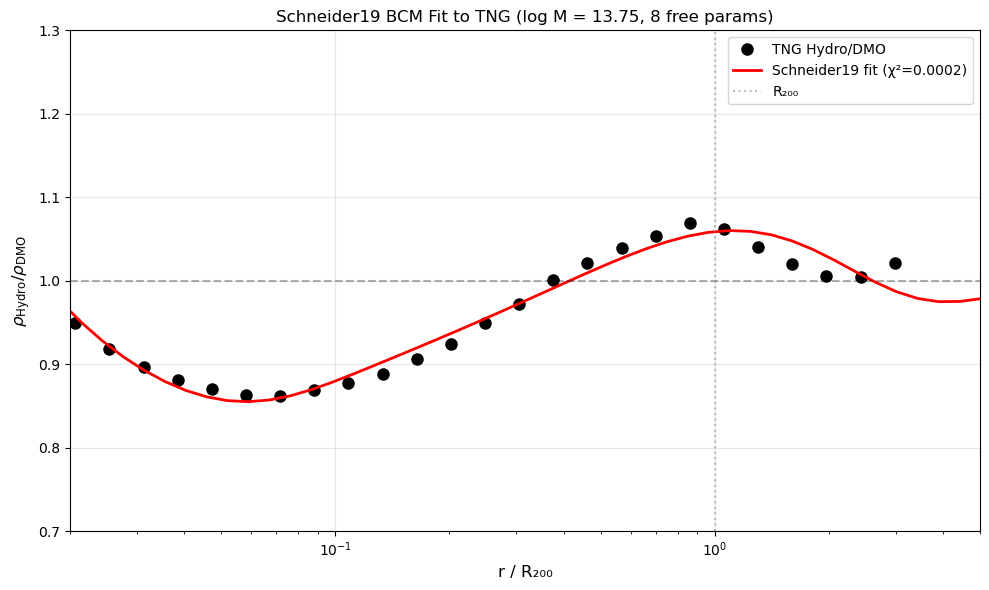


Fitted parameters (8 free):
  theta_ej: 2.1718
  theta_co: 0.0498
  log_M_c: 12.0006
  mu_beta: 0.1000
  gamma: 1.5000
  delta: 7.4437
  A: 0.0154
  log_M1: 10.1919


In [11]:
# Visualize the Schneider19 fit (8 free params)
fig, ax = plt.subplots(figsize=(10, 6))

# TNG data
ax.semilogx(r_fit, ratio_tng, 'ko', ms=8, label='TNG Hydro/DMO')

# BCM fit - all 8 params from optimization
best_params = dict(zip(param_names, result.x))
full_params = {
    'theta_ej': best_params['theta_ej'],
    'theta_co': best_params['theta_co'],
    'M_c': 10**best_params['log_M_c'] / h,
    'mu_beta': best_params['mu_beta'],
    'gamma': best_params['gamma'],
    'delta': best_params['delta'],
    'A': best_params['A'],                    # Now from optimization
    'M1': 10**best_params['log_M1'] / h,      # Now from optimization
    'eta': FIXED_PARAMS['eta'],
    'eta_delta': FIXED_PARAMS['eta_delta'],
    'tau': FIXED_PARAMS['tau'],
    'tau_delta': FIXED_PARAMS['tau_delta'],
    'epsilon_h': FIXED_PARAMS['epsilon_h'],
    'a': FIXED_PARAMS['a'],
    'n': FIXED_PARAMS['n'],
    'epsilon': FIXED_PARAMS['epsilon'],
    'p': FIXED_PARAMS['p'],
    'q': FIXED_PARAMS['q'],
}

dmo = bfg.Profiles.Schneider19.DarkMatterOnly(**full_params)
dmb = bfg.Profiles.Schneider19.DarkMatterBaryon(**full_params)

r_plot = np.logspace(-2, 0.7, 50)
r_phys_plot = r_plot * R200
M = 10**mass_center / h

rho_dmo = dmo.real(cosmo_ccl, r_phys_plot, M, 1.0)
rho_dmb = dmb.real(cosmo_ccl, r_phys_plot, M, 1.0)
ratio_bcm = rho_dmb / rho_dmo

ax.semilogx(r_plot, ratio_bcm, 'r-', lw=2, label=f'Schneider19 fit (χ²={result.fun:.4f})')

ax.axhline(1, color='k', ls='--', alpha=0.3)
ax.axvline(1, color='gray', ls=':', alpha=0.5, label='R₂₀₀')
ax.set_xlabel('r / R₂₀₀', fontsize=12)
ax.set_ylabel(r'$\rho_{\rm Hydro} / \rho_{\rm DMO}$', fontsize=12)
ax.set_title(f'Schneider19 BCM Fit to TNG (log M = {mass_center}, 8 free params)', fontsize=12)
ax.set_xlim(0.02, 5)
ax.set_ylim(0.7, 1.3)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print all fitted parameter values
print("\nFitted parameters (8 free):")
for name in param_names:
    print(f"  {name}: {best_params[name]:.4f}")

## Comparison: TNG Profiles vs Arico20 vs Schneider19 BCM Fits

Compare the TNG hydro/DMO profile ratios with the best-fit BCM predictions from both Arico20 and Schneider19 models.

In [79]:
# Load all fit parameters and TNG profiles for comparison
import json
import h5py
import numpy as np
import matplotlib.pyplot as plt
import BaryonForge as bfg
import pyccl as ccl

# Setup cosmology
h = 0.6774
cosmo_ccl = ccl.Cosmology(
    Omega_c=0.2603, Omega_b=0.0486, h=h, sigma8=0.8159, n_s=0.9667,
    matter_power_spectrum='linear'
)

# Load TNG profiles
PROFILE_PATH = '/mnt/home/mlee1/ceph/hydro_replace_fields/L205n2500TNG/profiles/profiles_snap096.h5'

with h5py.File(PROFILE_PATH, 'r') as f:
    r_edges = f.attrs['radial_bins']
    r_centers = np.sqrt(r_edges[:-1] * r_edges[1:])
    mass_bin_edges = f.attrs['mass_bin_edges']
    stacked_dmo = f['stacked_dmo'][:]
    stacked_hydro = f['stacked_hydro'][:]

# Profile ratio (target)
profile_ratio_tng = stacked_hydro / stacked_dmo

# Load Arico20 mass-dependent fits
with open('/mnt/home/mlee1/hydro_replace2/config/bcm_fits/bcm_tng_fit_arico20_mass_dependent.json') as f:
    arico20_fits = json.load(f)

# Load Schneider19 fits (from checkpoint files - use best so far)
schneider19_fits = {}
for bin_name in ['low', 'mid_low', 'mid_high', 'high']:
    checkpoint_path = f'/mnt/home/mlee1/hydro_replace2/config/bcm_fits/bcm_tng_fit_schneider19_M{bin_name}_restarts.json'
    try:
        with open(checkpoint_path) as f:
            data = json.load(f)
            # Find best restart
            best_restart = min(data['restarts'], key=lambda x: x['chi2'])
            schneider19_fits[bin_name] = {
                'mass_range': data['mass_range'],
                'chi2': best_restart['chi2'],
                'params': best_restart['params'],
                'n_restarts': data['n_restarts_completed']
            }
    except FileNotFoundError:
        print(f"Schneider19 {bin_name} not yet available")

print("Loaded fits:")
print(f"  Arico20: {list(arico20_fits.keys())}")
print(f"  Schneider19: {list(schneider19_fits.keys())}")

# Mass bin info
MASS_BINS = {
    'low': {'idx': 0, 'log_M': 12.25, 'R200': 0.15, 'label': r'$10^{12.0-12.5}$'},
    'mid_low': {'idx': 1, 'log_M': 12.75, 'R200': 0.24, 'label': r'$10^{12.5-13.0}$'},
    'mid_high': {'idx': 2, 'log_M': 13.25, 'R200': 0.38, 'label': r'$10^{13.0-13.5}$'},
    'high': {'idx': 3, 'log_M': 13.75, 'R200': 0.60, 'label': r'$10^{13.5-14.0}$'},
}

# Fitting range
R_MIN, R_MAX = 0.02, 3.0

Loaded fits:
  Arico20: ['low', 'mid_low', 'mid_high', 'high']
  Schneider19: ['low', 'mid_low', 'mid_high', 'high']


In [80]:
# Functions to compute BCM profile ratios

def compute_arico20_ratio(r_R200, R200, log_M, params):
    """Compute Arico20 BCM profile ratio at given r/R200."""
    r_phys = r_R200 * R200  # Mpc/h
    M = 10**log_M / h       # Msun (CCL units)
    
    # Build parameter dict for Arico20 (fitted + fixed params)
    arico_params = dict(
        # Fitted parameters
        M_c=10**params['log_M_c'],
        mu=params['mu'],
        beta=params['beta'],
        M_inn=10**params['log_M_inn'],
        theta_inn=params['theta_inn'],
        theta_out=params['theta_out'],
        eta=params['eta'],
        M1_0=10**params['log_M1_0'],
        # Fixed parameters (required by BaryonForge)
        epsilon_hydro=np.sqrt(5),
        theta_rg=0.3,
        sigma_rg=0.1,
        M_r=1e18,
        beta_r=2,
        alpha_g=2,
        epsilon_h=0.015,
        M1_fsat=3.98,
        eps_fsat=1.0,
        alpha_fsat=1.0,
        delta_fsat=0.99,
        gamma_fsat=1.67,
        a=0.3,
        n=2,
        p=0.3,
        q=0.707,
        A_nt=0.495,
        T_w=10**6.5,
        alpha_nt=0.1,
        mean_molecular_weight=0.59,
    )
    
    dmo = bfg.Profiles.Arico20.DarkMatterOnly(**arico_params)
    dmb = bfg.Profiles.Arico20.DarkMatterBaryon(**arico_params)
    
    rho_dmo = dmo.real(cosmo_ccl, r_phys, M, 1.0)
    rho_dmb = dmb.real(cosmo_ccl, r_phys, M, 1.0)
    
    # Handle invalid values
    valid = (rho_dmo > 0) & np.isfinite(rho_dmo) & np.isfinite(rho_dmb)
    ratio = np.ones_like(r_R200)
    ratio[valid] = rho_dmb[valid] / rho_dmo[valid]
    
    return ratio

def compute_schneider19_ratio(r_R200, R200, log_M, params):
    """Compute Schneider19 BCM profile ratio at given r/R200."""
    r_phys = r_R200 * R200  # Mpc/h
    M = 10**log_M / h       # Msun (CCL units)
    
    # Fixed parameters
    fixed = {
        'eta': 0.3, 'eta_delta': 0.2,
        'tau': -1.5, 'tau_delta': 0.0, 'epsilon_h': 0.015,
        'a': 0.3, 'n': 2.0, 'epsilon': 4.0, 'p': 0.3, 'q': 0.707,
    }
    
    # Build full parameter dict
    s19_params = dict(
        theta_ej=params['theta_ej'],
        theta_co=params['theta_co'],
        M_c=10**params['log_M_c'] / h,
        mu_beta=params['mu_beta'],
        gamma=params['gamma'],
        delta=params['delta'],
        A=params['A'],
        M1=10**params['log_M1'] / h,
        **fixed
    )
    
    dmo = bfg.Profiles.Schneider19.DarkMatterOnly(**s19_params)
    dmb = bfg.Profiles.Schneider19.DarkMatterBaryon(**s19_params)
    
    rho_dmo = dmo.real(cosmo_ccl, r_phys, M, 1.0)
    rho_dmb = dmb.real(cosmo_ccl, r_phys, M, 1.0)
    
    # Handle invalid values
    valid = (rho_dmo > 0) & np.isfinite(rho_dmo) & np.isfinite(rho_dmb)
    ratio = np.ones_like(r_R200)
    ratio[valid] = rho_dmb[valid] / rho_dmo[valid]
    
    return ratio

print("BCM profile functions defined (with full Arico20 fixed params).")

BCM profile functions defined (with full Arico20 fixed params).


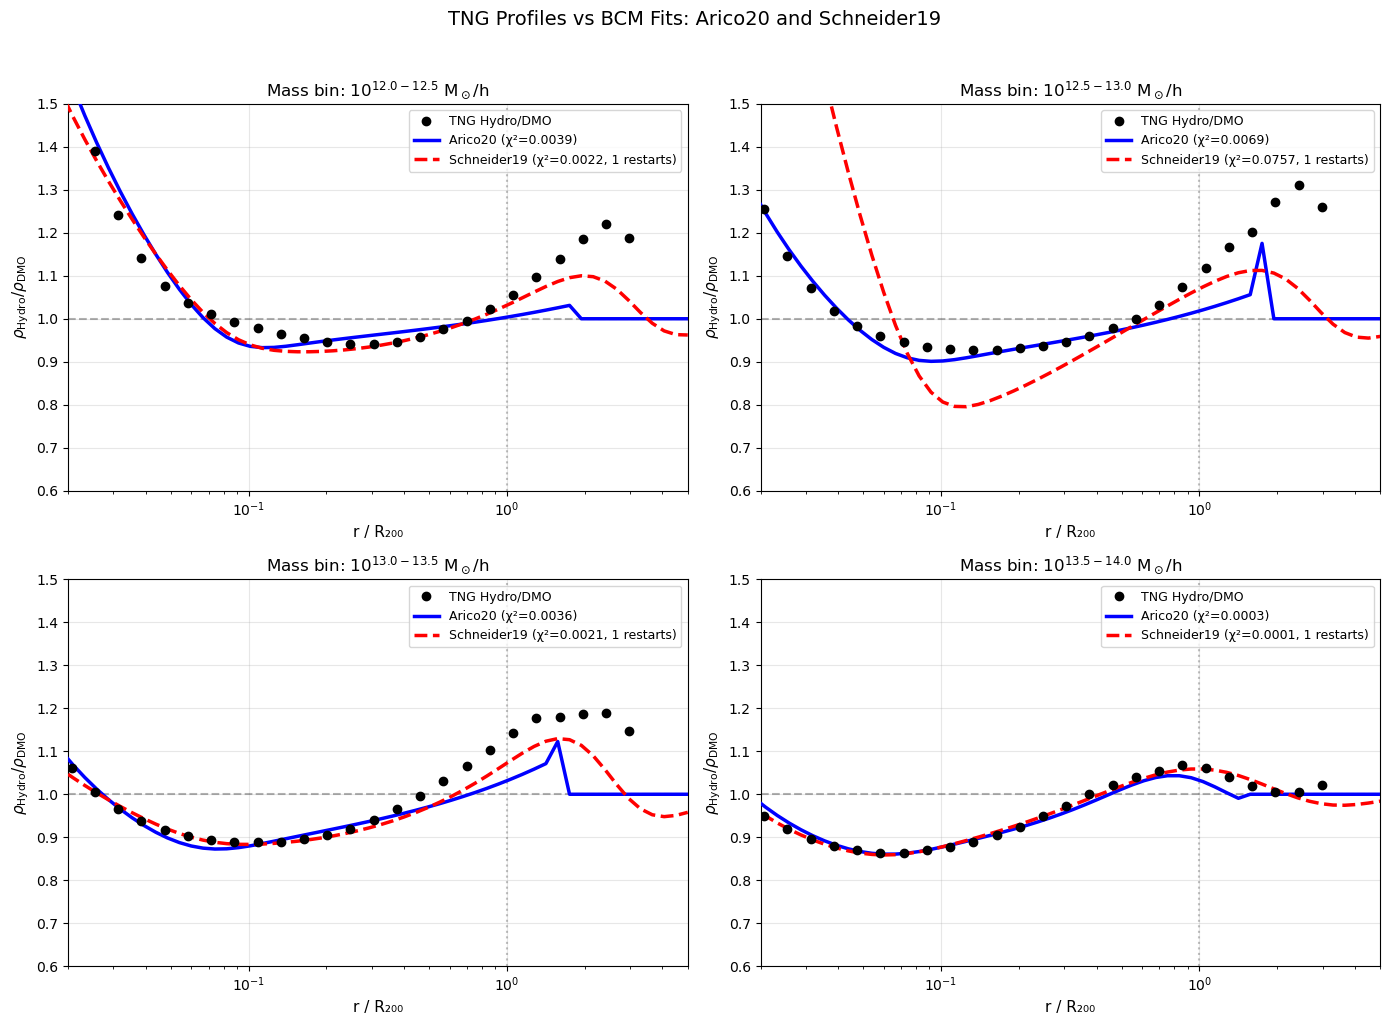


Saved: figures/bcm_comparison_arico20_schneider19.png


In [81]:
# Plot comparison: TNG vs Arico20 vs Schneider19 for all mass bins
import warnings

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# Plot radii
r_plot = np.logspace(-2, 0.7, 60)

for ax, (bin_name, bin_info) in zip(axes, MASS_BINS.items()):
    idx = bin_info['idx']
    log_M = bin_info['log_M']
    R200 = bin_info['R200']
    
    # TNG data
    valid = (r_centers >= R_MIN) & (r_centers <= R_MAX) & (stacked_dmo[idx] > 0)
    r_tng = r_centers[valid]
    ratio_tng = profile_ratio_tng[idx][valid]
    
    # Plot TNG
    ax.semilogx(r_tng, ratio_tng, 'ko', ms=6, label='TNG Hydro/DMO', zorder=10)
    
    # Arico20 BCM (suppress warnings for plaw_fourier mismatch)
    if bin_name in arico20_fits:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                ratio_arico = compute_arico20_ratio(r_plot, R200, log_M, arico20_fits[bin_name]['params'])
            chi2_arico = arico20_fits[bin_name]['chi2']
            ax.semilogx(r_plot, ratio_arico, 'b-', lw=2.5, 
                       label=f'Arico20 (χ²={chi2_arico:.4f})', zorder=5)
        except Exception as e:
            print(f"Arico20 {bin_name} failed: {e}")
    
    # Schneider19 BCM
    if bin_name in schneider19_fits:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                ratio_s19 = compute_schneider19_ratio(r_plot, R200, log_M, schneider19_fits[bin_name]['params'])
            chi2_s19 = schneider19_fits[bin_name]['chi2']
            n_restarts = schneider19_fits[bin_name]['n_restarts']
            ax.semilogx(r_plot, ratio_s19, 'r--', lw=2.5, 
                       label=f'Schneider19 (χ²={chi2_s19:.4f}, {n_restarts} restarts)', zorder=5)
        except Exception as e:
            print(f"Schneider19 {bin_name} failed: {e}")
    else:
        ax.text(0.5, 0.15, 'Schneider19: fitting in progress...', 
               transform=ax.transAxes, fontsize=10, color='red', ha='center')
    
    # Formatting
    ax.axhline(1, color='k', ls='--', alpha=0.3)
    ax.axvline(1, color='gray', ls=':', alpha=0.5)
    ax.set_xlabel('r / R₂₀₀', fontsize=11)
    ax.set_ylabel(r'$\rho_{\rm Hydro} / \rho_{\rm DMO}$', fontsize=11)
    ax.set_title(f'Mass bin: {bin_info["label"]} M$_\\odot$/h', fontsize=12)
    ax.set_xlim(0.02, 5)
    ax.set_ylim(0.6, 1.5)
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('TNG Profiles vs BCM Fits: Arico20 and Schneider19', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('figures/bcm_comparison_arico20_schneider19.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSaved: figures/bcm_comparison_arico20_schneider19.png")

In [ ]:
# Summary table comparing fit quality
print("=" * 80)
print("BCM FIT COMPARISON: Arico20 vs Schneider19")
print("=" * 80)
print(f"{'Mass Bin':<15} {'log M range':<15} {'Arico20 χ²':<15} {'Schneider19 χ²':<20}")
print("-" * 80)

for bin_name, bin_info in MASS_BINS.items():
    mass_range = f"{bin_info['log_M']-0.25:.1f}-{bin_info['log_M']+0.25:.1f}"
    
    chi2_arico = arico20_fits[bin_name]['chi2'] if bin_name in arico20_fits else float('nan')
    
    if bin_name in schneider19_fits:
        chi2_s19 = schneider19_fits[bin_name]['chi2']
        n_restarts = schneider19_fits[bin_name]['n_restarts']
        s19_str = f"{chi2_s19:.6f} ({n_restarts}/10)"
    else:
        s19_str = "In progress..."
    
    print(f"{bin_name:<15} {mass_range:<15} {chi2_arico:<15.6f} {s19_str:<20}")

print("-" * 80)
print("\nNotes:")
print("  • Arico20: 8 free parameters, fitted with differential evolution")
print("  • Schneider19: 8 free parameters, fitted with L-BFGS-B (10 random restarts)")
print("  • Lower χ² = better fit to TNG profile ratios")
print("=" * 80)